# Atividade MC 2 - Implementação de Gradiente Descendente e Redes Neurais

Bibliotecas necessárias:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Questão A: Gradiente Descendente (Regressão Linear - Intercepto)

**Objetivo:** Implementar o procedimento dos slides 156-213, otimizando apenas o **Intercept**, com o **Slope fixo em 0.64**.
* **Modelo:** $Altura = Intercept + 0.64 \times Peso$.
* **Início:** Intercepto inicial em **0.0**.
* **Condições de parada:** Máximo de iterações: $\mathbf{50}$ OU $\lvert Step Size \rvert < \mathbf{0.001}$.
* **Visualização:** Mostrar o movimento da reta e a descida na curva de custo (SSR) a cada iteração.
* **LRs a testar:** 0.1 e 0.01.

In [2]:
# --- Dados da Questão A ---
weights = np.array([0.5, 2.3, 2.9])
heights = np.array([1.4, 1.9, 3.2])
slope_fixed = 0.64
max_iters = 50
tolerance = 0.001
initial_intercept = 0.0

# --- Funções para Gradiente Descendente (1 Parâmetro) ---

# Função de Custo (Sum of Squared Residuals - SSR)
def calculate_ssr(intercept, slope, weights, heights):
    predicted = intercept + slope * weights
    residuals = heights - predicted
    ssr = np.sum(residuals**2)
    return ssr

# Derivada do SSR em relação ao Intercept (Gradiente)
def calculate_gradient_intercept(intercept, slope, weights, heights):
    predicted = intercept + slope * weights
    residuals = heights - predicted
    # d(SSR)/d(Intercept) = sum(-2 * residuals)
    derivative = np.sum(-2 * residuals)
    return derivative

def run_gradient_descent_and_plot(weights, heights, slope_fixed, initial_intercept, learning_rate, max_iters, tolerance, lr_label):
    
    print(f"\n--- Iniciando Gradiente Descendente (LR: {lr_label}) ---")

    intercept = initial_intercept
    intercept_history = [intercept]
    ssr_history = [calculate_ssr(intercept, slope_fixed, weights, heights)]
    
    # Valores para plotagem da curva SSR completa
    intercept_vals = np.linspace(-0.5, 1.5, 100)
    ssr_vals = [calculate_ssr(i, slope_fixed, weights, heights) for i in intercept_vals]

    for i in range(max_iters):
        # 1. Calcular o Gradiente
        derivative = calculate_gradient_intercept(intercept, slope_fixed, weights, heights)
        
        # 2. Calcular o Step Size
        step_size = derivative * learning_rate
            
        # 4. Atualizar o Intercept
        old_intercept = intercept
        intercept = intercept - step_size
        
        # Atualizar histórico para plotagem
        intercept_history.append(intercept)
        ssr_history.append(calculate_ssr(intercept, slope_fixed, weights, heights))

        # 5. Imprimir informações a cada iteração
        print(f"Iter {i+1}: Old I={old_intercept:.3f}, Step Size={step_size:.3f}, New I={intercept:.3f}, Grad={derivative:.3f}")

        # 6. Mostrar o movimento da reta e a descida na curva a CADA iteração
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Gráfico 1: Movimento da Reta
        axes[0].scatter(weights, heights, color='teal', s=100, alpha=0.6, label='Dados')
        predicted_all = intercept + slope_fixed * weights
        
        # Mostrar o movimento da reta (current line)
        axes[0].plot(weights, predicted_all, color='red', linewidth=2, label=f'Reta (I={intercept:.3f})')
        axes[0].set_title(f"Iteração {i+1}: Movimento da Reta (LR: {lr_label})")
        axes[0].set_xlabel("Peso")
        axes[0].set_ylabel("Altura")
        axes[0].legend()
        axes[0].set_ylim(0, 4)
        axes[0].set_xlim(0, 3.5)
        
        # Gráfico 2: SSR Curve e Progresso
        axes[1].plot(intercept_vals, ssr_vals, label='Curva SSR', color='blue')
        # Plotar o caminho percorrido
        axes[1].plot(intercept_history[:-1], ssr_history[:-1], color='red', marker='o', markersize=4, linestyle='--', linewidth=1, label='Passos Anteriores')
        # Marcar o passo atual
        axes[1].scatter(intercept, ssr_history[-1], color='red', marker='D', s=100, zorder=5, label=f'Atual (SSR={ssr_history[-1]:.3f})')

        axes[1].set_title(f"Iteração {i+1}: Descida na Curva de Custo (SSR)")
        axes[1].set_xlabel("Intercept")
        axes[1].set_ylabel("SSR")
        axes[1].legend()
        plt.show()

        # 3. Condição de Parada (Step Size pequeno)
        if abs(step_size) < tolerance:
            print(f"-> Convergência alcançada (Step Size < {tolerance}) na iteração {i+1}.")
            break

    if i == max_iters - 1 and abs(step_size) >= tolerance:
        print("-> Condição de parada: Número máximo de iterações atingido (50).")
    
    print(f"Resultado Final para LR {lr_label}: Intercept = {intercept:.4f}")
    
    return intercept_history, ssr_history


--- Iniciando Gradiente Descendente (LR: 0.1) ---
Iter 1: Old I=0.000, Step Size=-0.570, New I=0.570, Grad=-5.704


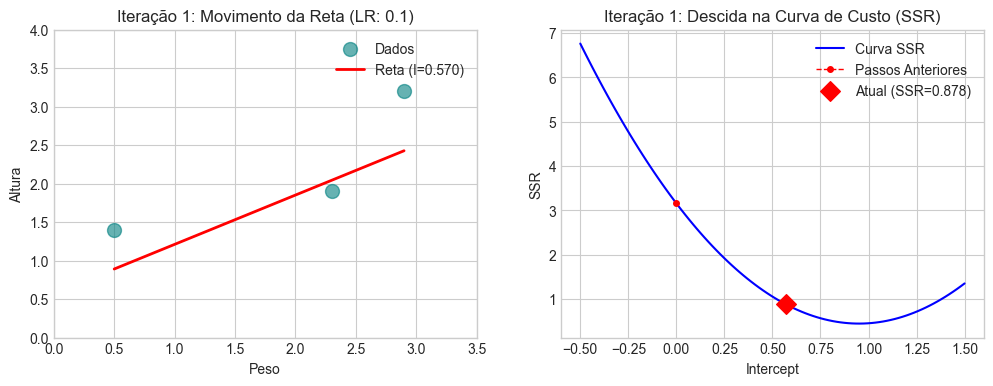

Iter 2: Old I=0.570, Step Size=-0.228, New I=0.799, Grad=-2.282


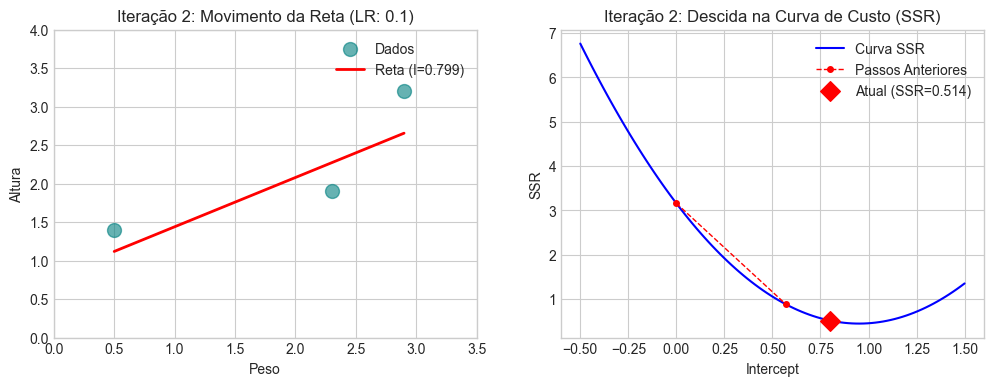

Iter 3: Old I=0.799, Step Size=-0.091, New I=0.890, Grad=-0.913


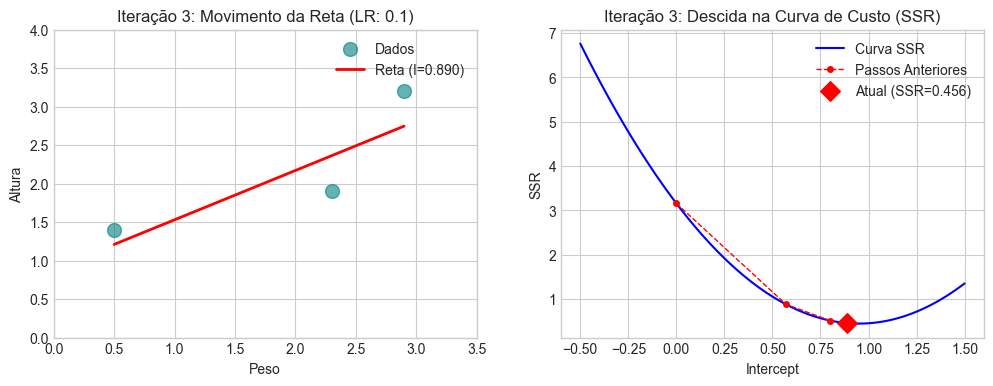

Iter 4: Old I=0.890, Step Size=-0.037, New I=0.926, Grad=-0.365


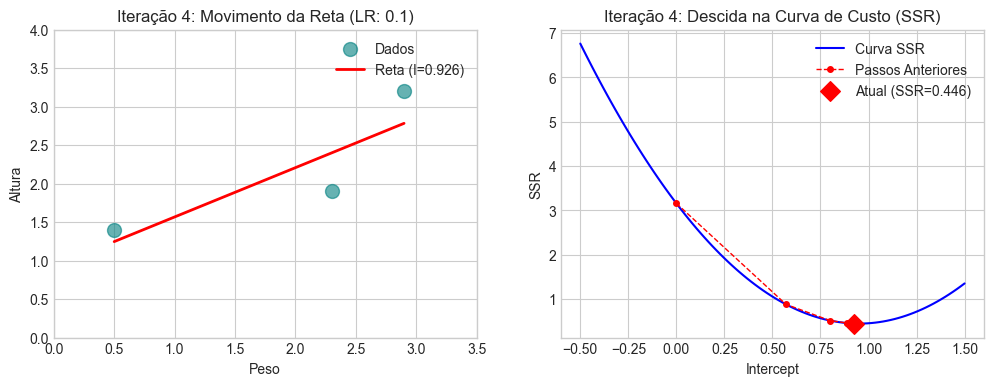

Iter 5: Old I=0.926, Step Size=-0.015, New I=0.941, Grad=-0.146


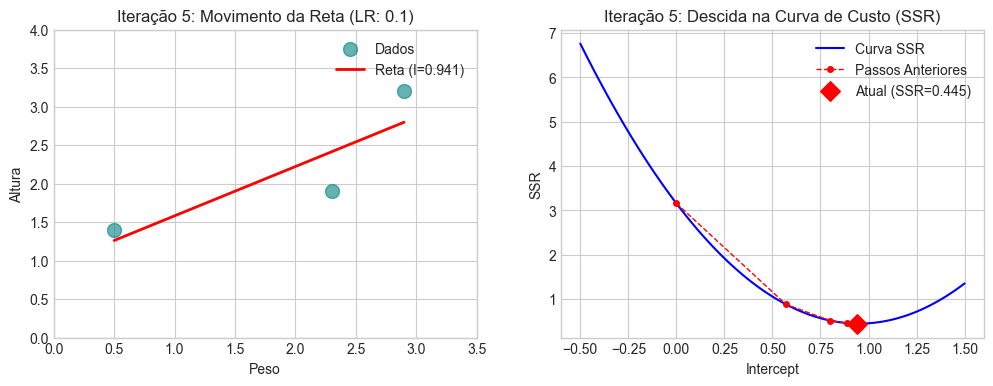

Iter 6: Old I=0.941, Step Size=-0.006, New I=0.947, Grad=-0.058


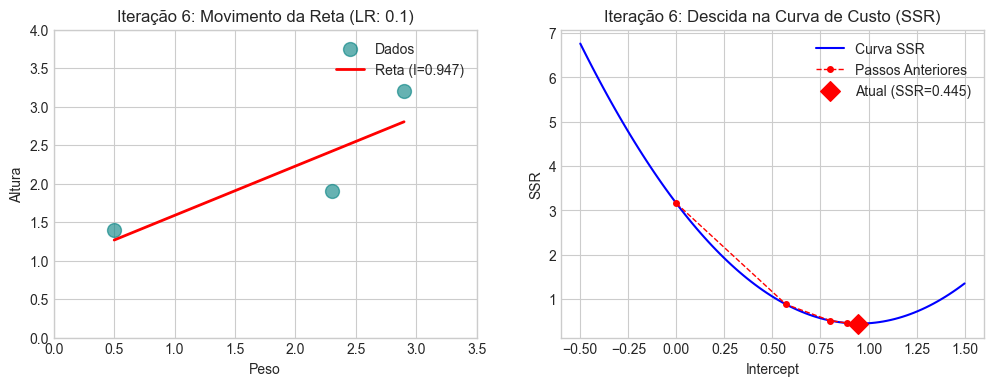

Iter 7: Old I=0.947, Step Size=-0.002, New I=0.949, Grad=-0.023


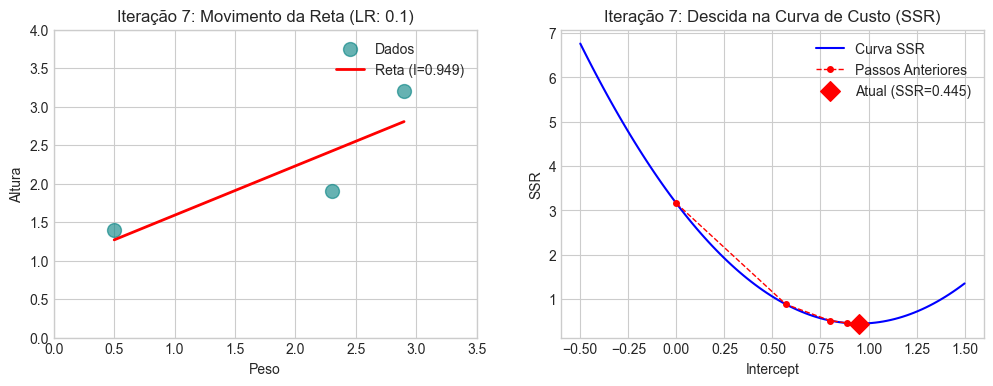

Iter 8: Old I=0.949, Step Size=-0.001, New I=0.950, Grad=-0.009


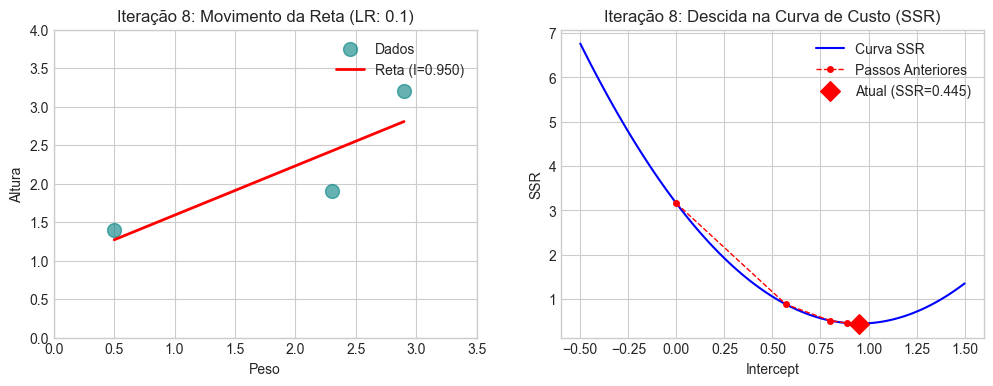

-> Convergência alcançada (Step Size < 0.001) na iteração 8.
Resultado Final para LR 0.1: Intercept = 0.9500

--- Iniciando Gradiente Descendente (LR: 0.01) ---
Iter 1: Old I=0.000, Step Size=-0.057, New I=0.057, Grad=-5.704


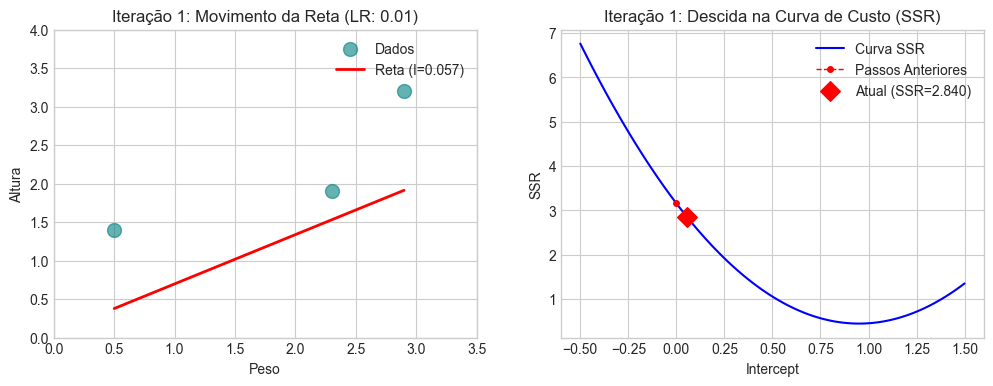

Iter 2: Old I=0.057, Step Size=-0.054, New I=0.111, Grad=-5.362


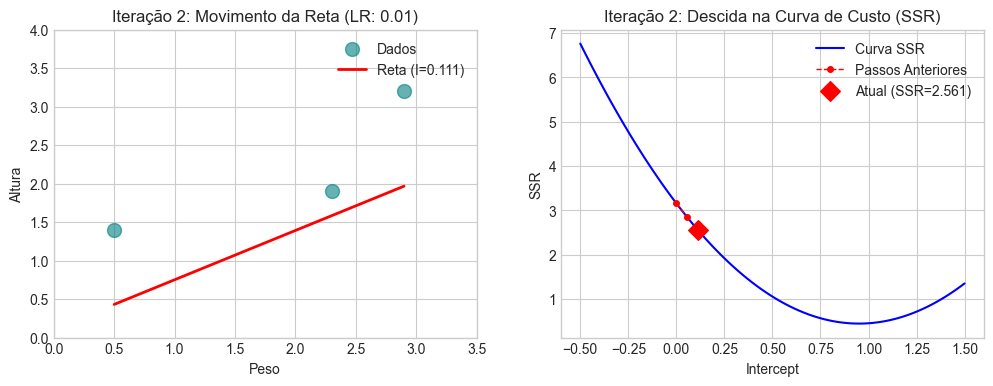

Iter 3: Old I=0.111, Step Size=-0.050, New I=0.161, Grad=-5.040


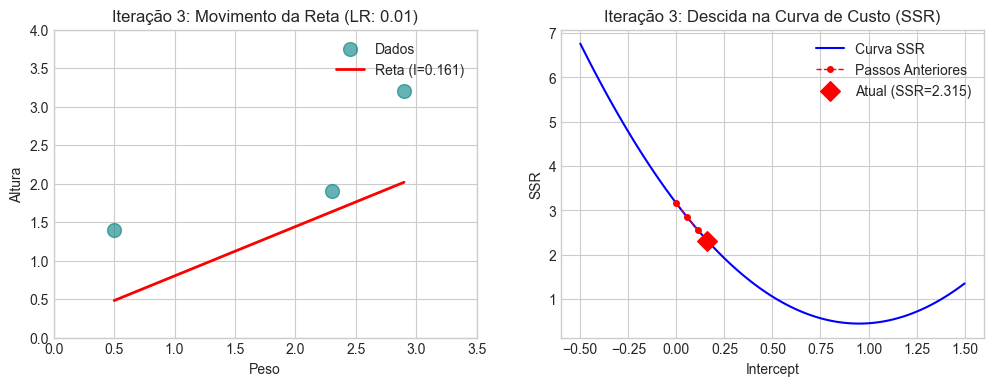

Iter 4: Old I=0.161, Step Size=-0.047, New I=0.208, Grad=-4.738


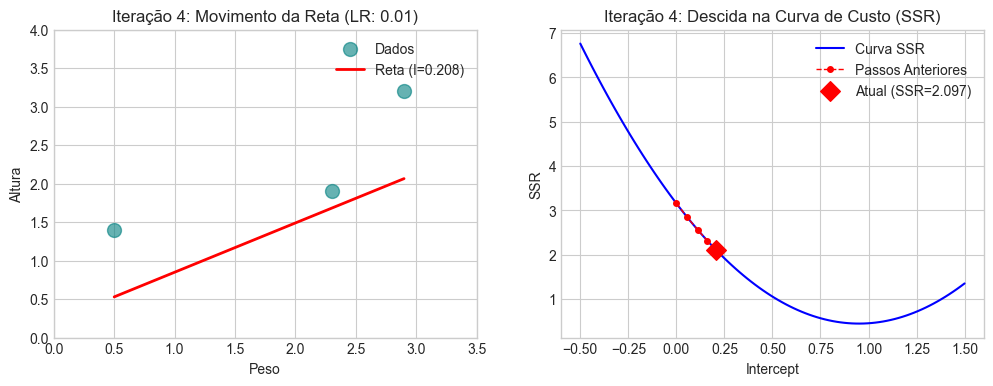

Iter 5: Old I=0.208, Step Size=-0.045, New I=0.253, Grad=-4.453


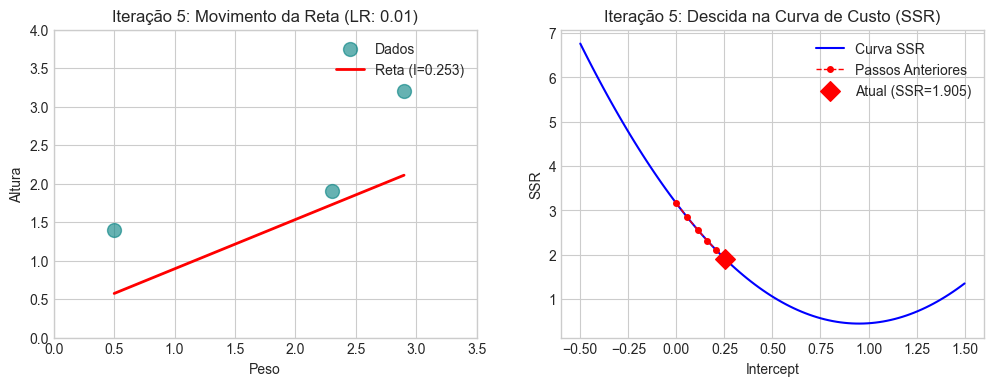

Iter 6: Old I=0.253, Step Size=-0.042, New I=0.295, Grad=-4.186


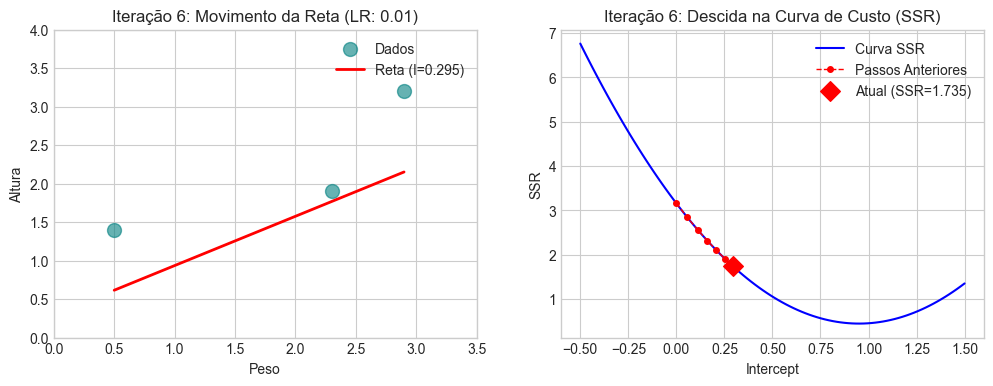

Iter 7: Old I=0.295, Step Size=-0.039, New I=0.334, Grad=-3.935


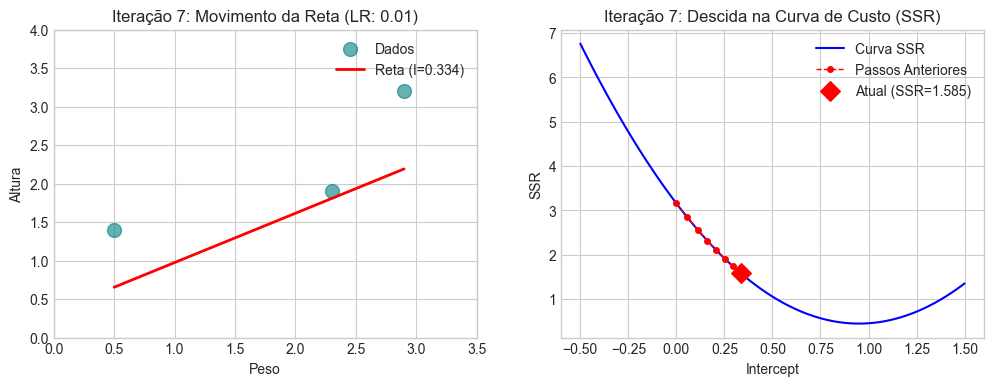

Iter 8: Old I=0.334, Step Size=-0.037, New I=0.371, Grad=-3.699


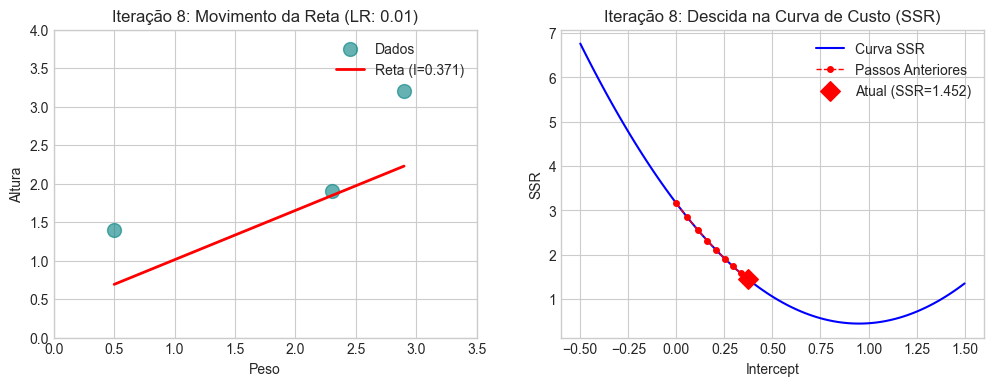

Iter 9: Old I=0.371, Step Size=-0.035, New I=0.406, Grad=-3.477


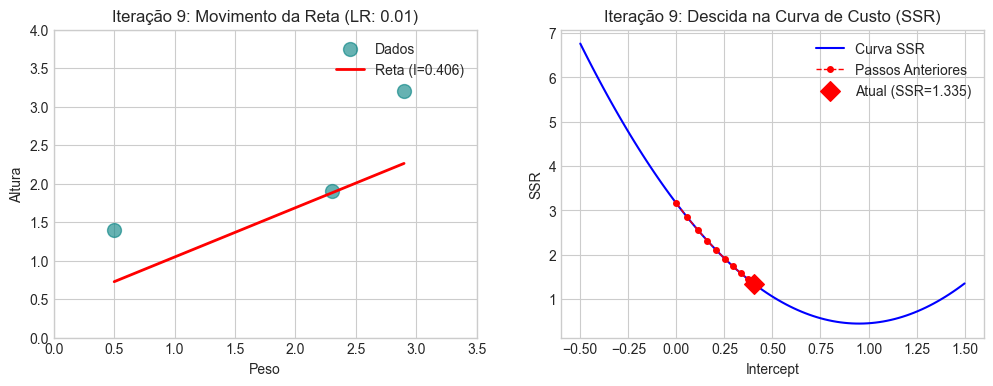

Iter 10: Old I=0.406, Step Size=-0.033, New I=0.439, Grad=-3.268


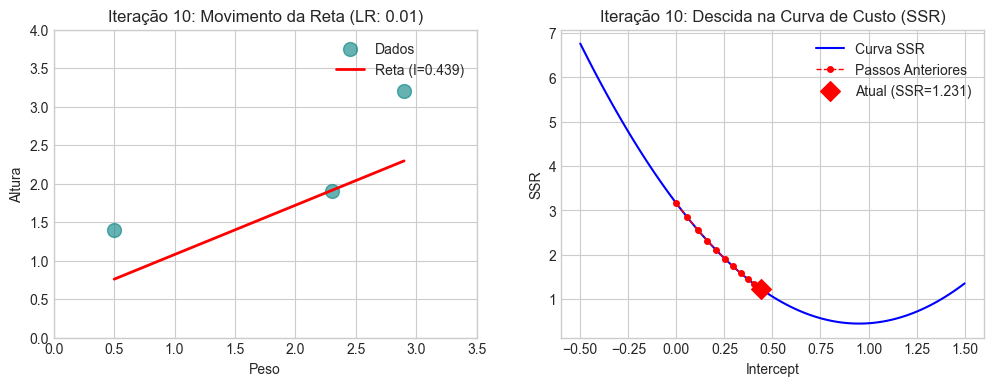

Iter 11: Old I=0.439, Step Size=-0.031, New I=0.469, Grad=-3.072


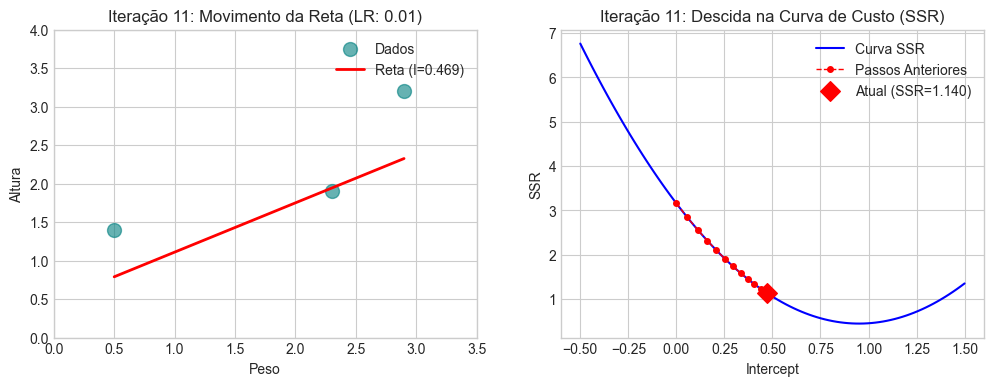

Iter 12: Old I=0.469, Step Size=-0.029, New I=0.498, Grad=-2.888


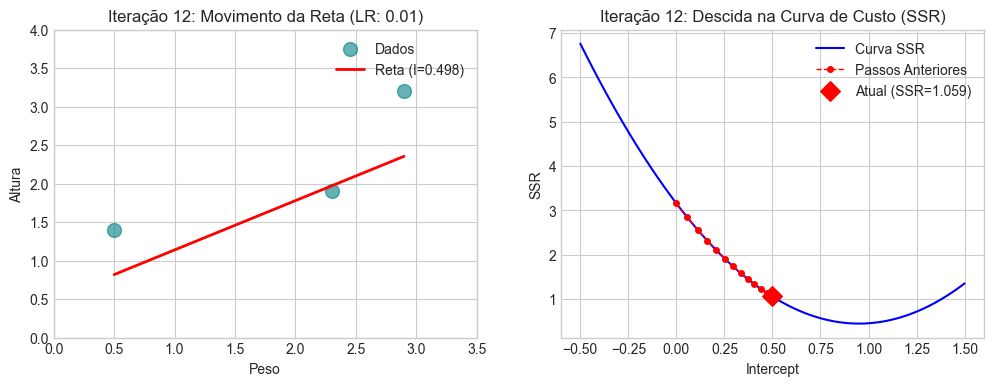

Iter 13: Old I=0.498, Step Size=-0.027, New I=0.525, Grad=-2.715


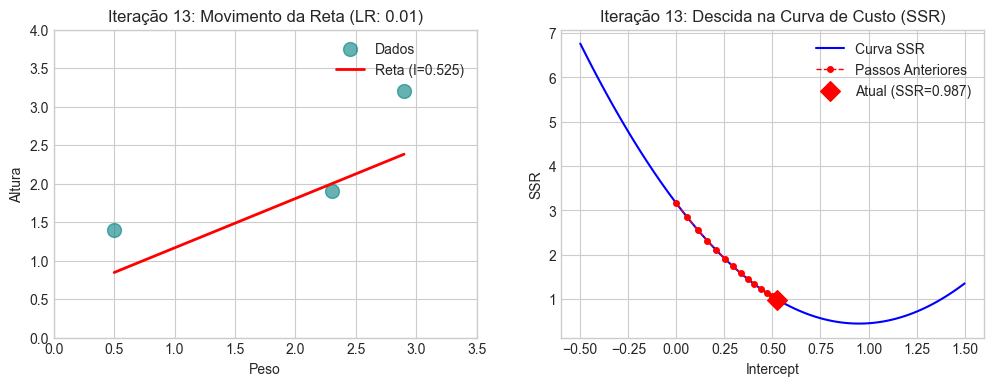

Iter 14: Old I=0.525, Step Size=-0.026, New I=0.551, Grad=-2.552


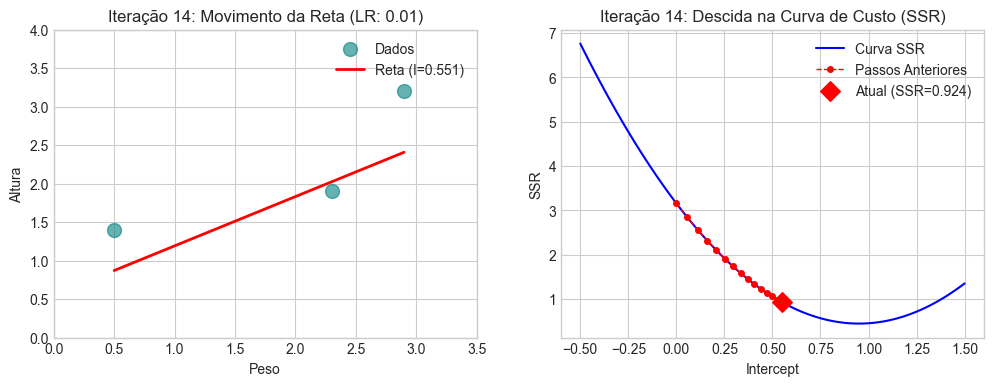

Iter 15: Old I=0.551, Step Size=-0.024, New I=0.575, Grad=-2.399


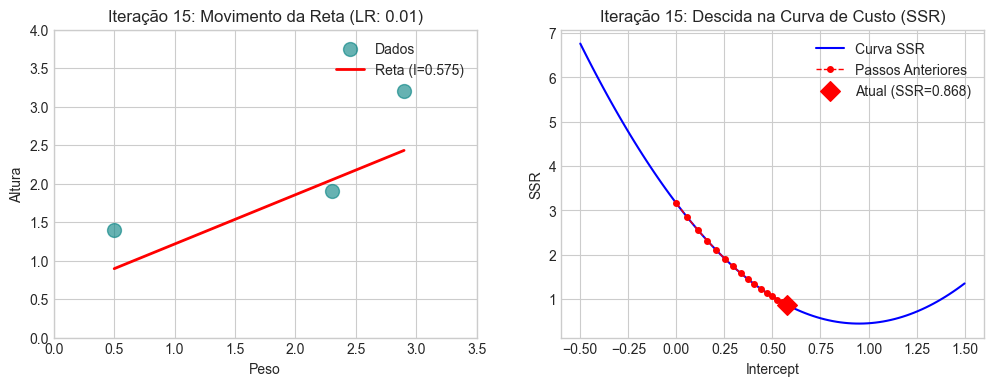

Iter 16: Old I=0.575, Step Size=-0.023, New I=0.597, Grad=-2.255


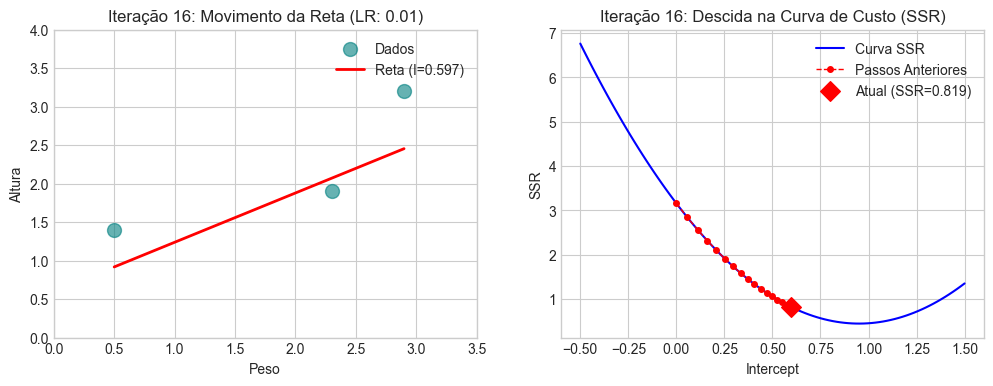

Iter 17: Old I=0.597, Step Size=-0.021, New I=0.619, Grad=-2.119


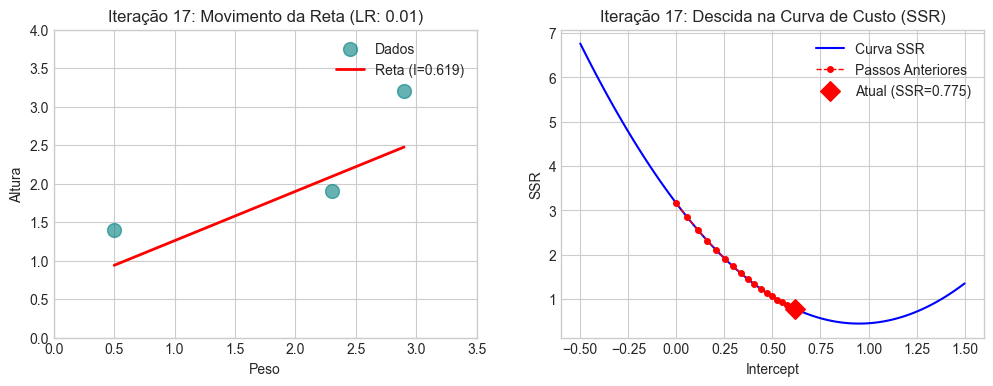

Iter 18: Old I=0.619, Step Size=-0.020, New I=0.639, Grad=-1.992


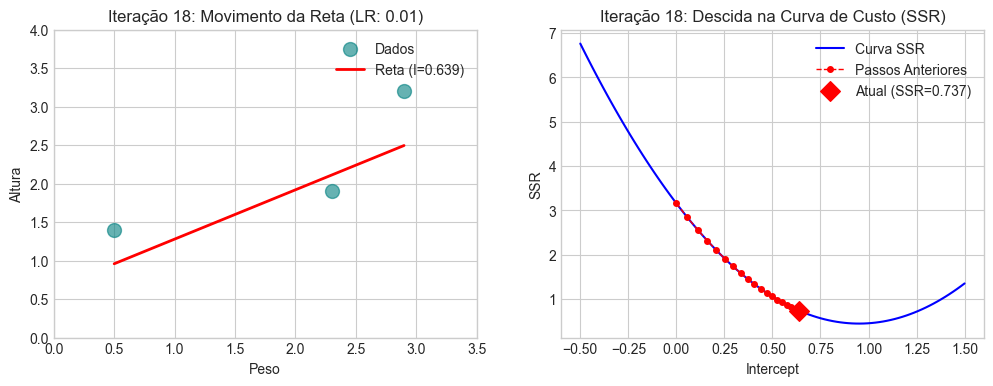

Iter 19: Old I=0.639, Step Size=-0.019, New I=0.657, Grad=-1.873


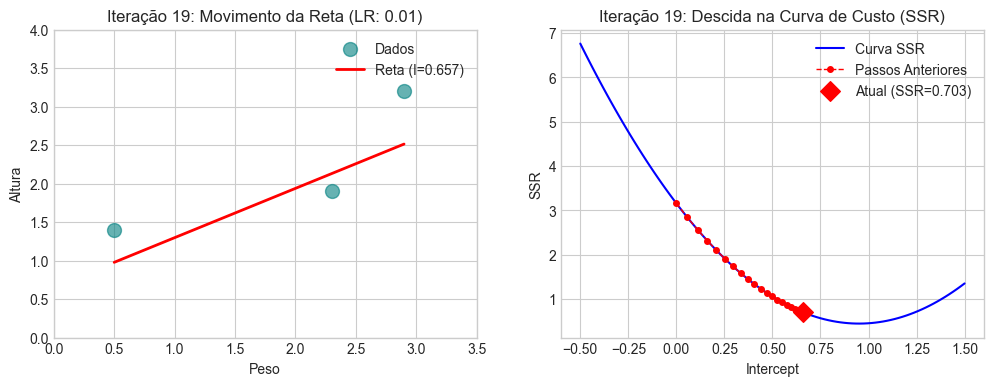

Iter 20: Old I=0.657, Step Size=-0.018, New I=0.675, Grad=-1.760


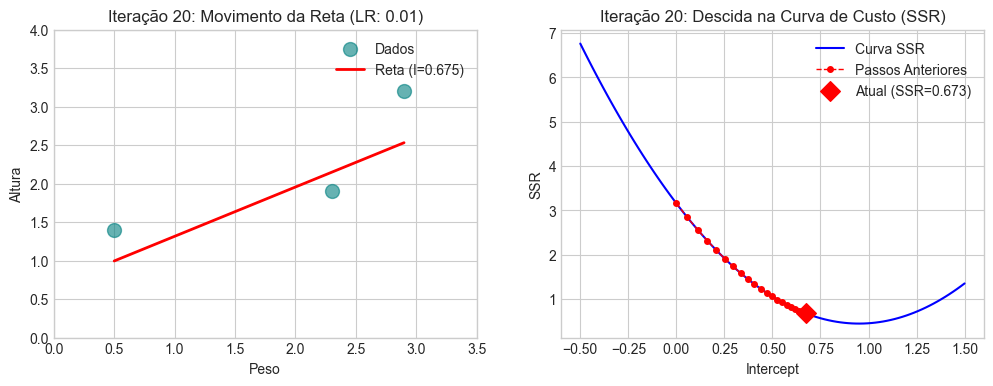

Iter 21: Old I=0.675, Step Size=-0.017, New I=0.691, Grad=-1.655


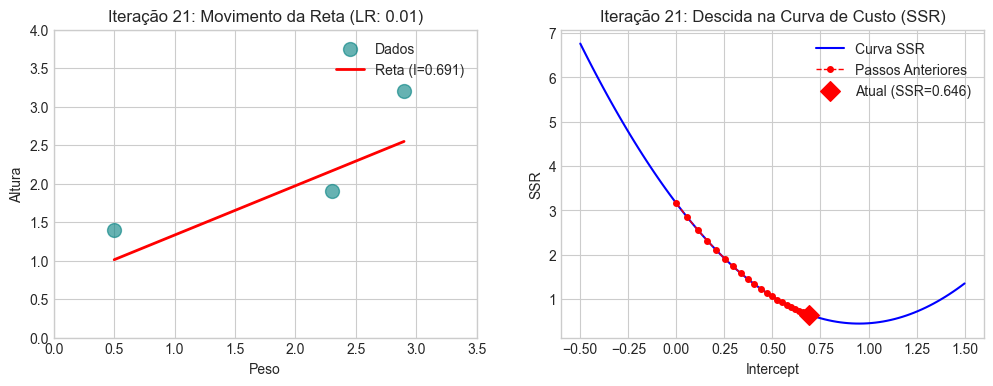

Iter 22: Old I=0.691, Step Size=-0.016, New I=0.707, Grad=-1.555


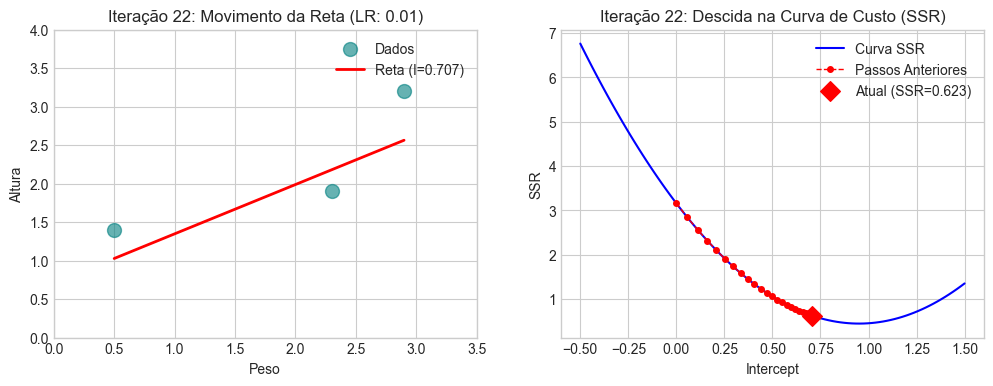

Iter 23: Old I=0.707, Step Size=-0.015, New I=0.722, Grad=-1.462


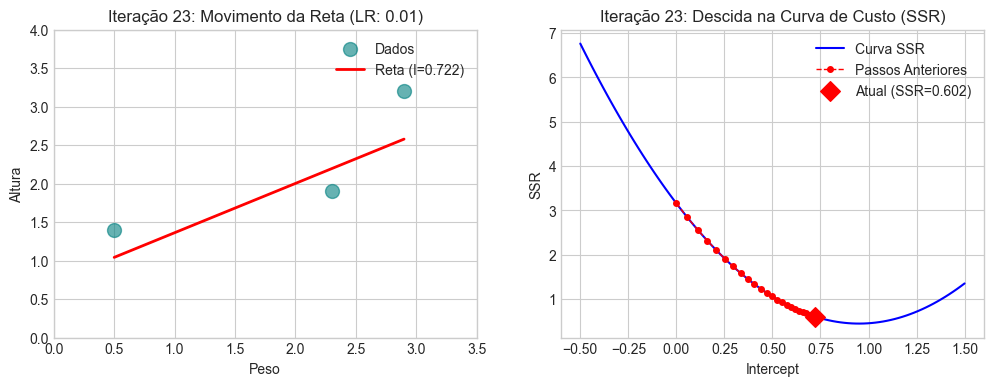

Iter 24: Old I=0.722, Step Size=-0.014, New I=0.735, Grad=-1.374


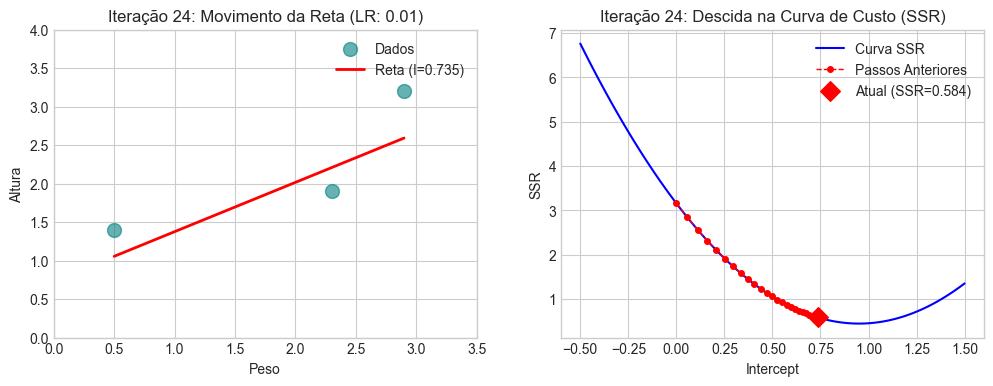

Iter 25: Old I=0.735, Step Size=-0.013, New I=0.748, Grad=-1.292


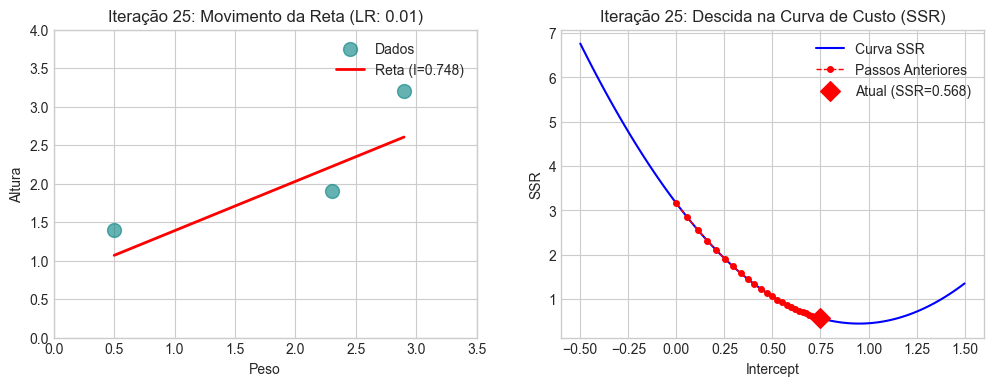

Iter 26: Old I=0.748, Step Size=-0.012, New I=0.760, Grad=-1.214


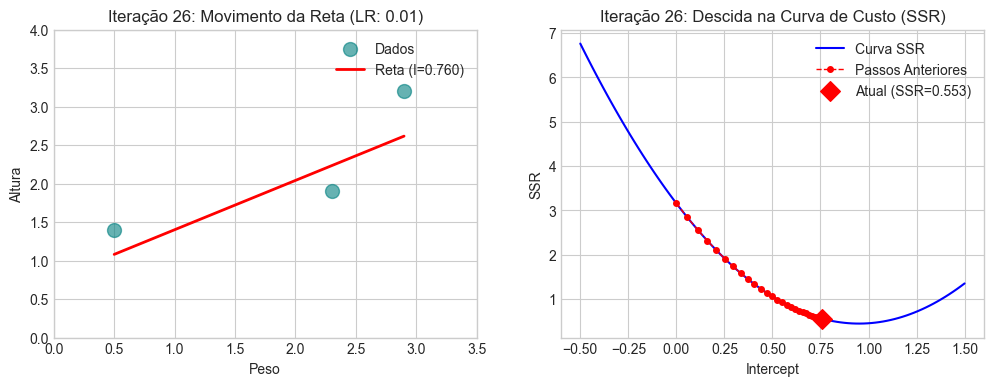

Iter 27: Old I=0.760, Step Size=-0.011, New I=0.772, Grad=-1.142


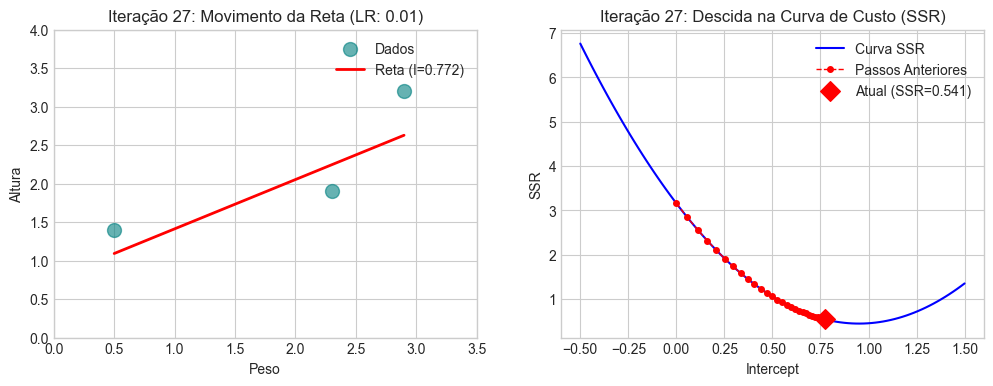

Iter 28: Old I=0.772, Step Size=-0.011, New I=0.783, Grad=-1.073


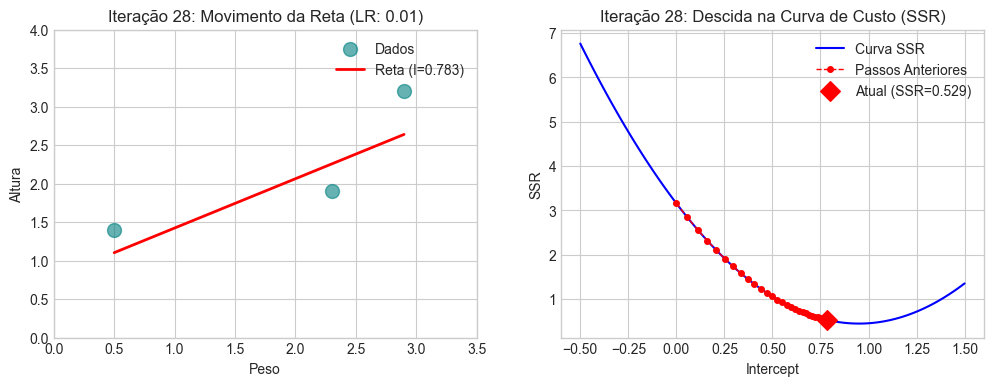

Iter 29: Old I=0.783, Step Size=-0.010, New I=0.793, Grad=-1.009


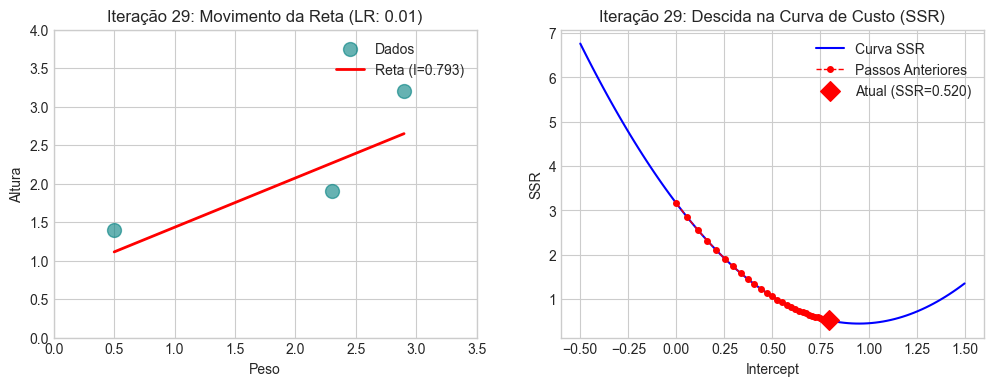

Iter 30: Old I=0.793, Step Size=-0.009, New I=0.802, Grad=-0.948


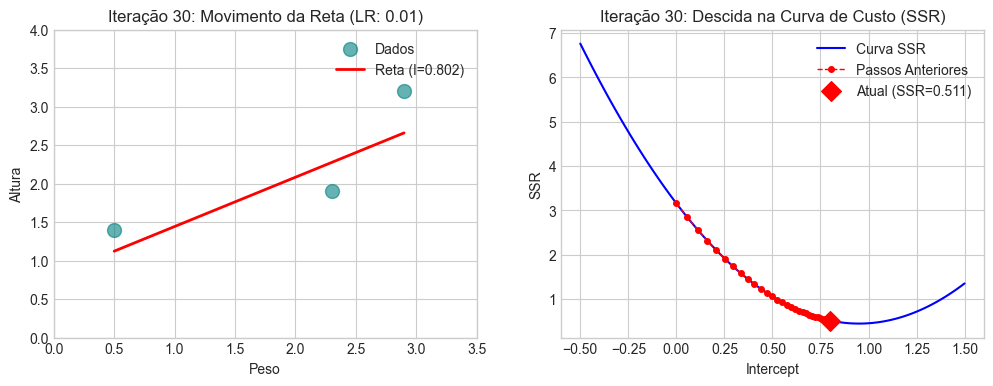

Iter 31: Old I=0.802, Step Size=-0.009, New I=0.811, Grad=-0.891


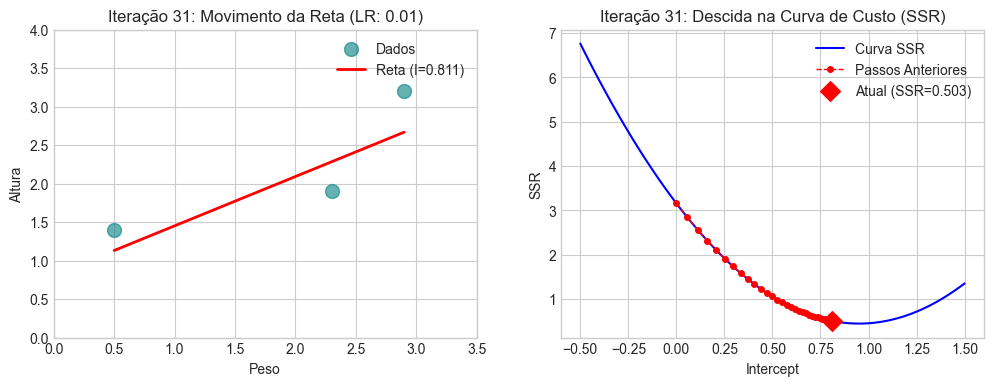

Iter 32: Old I=0.811, Step Size=-0.008, New I=0.819, Grad=-0.838


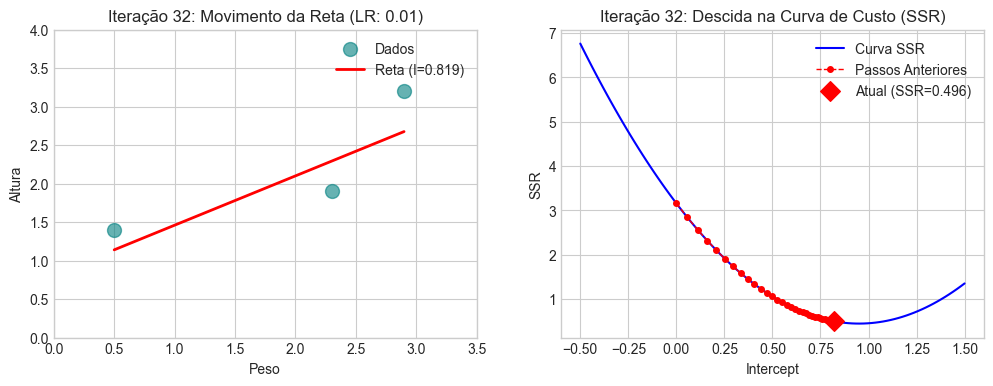

Iter 33: Old I=0.819, Step Size=-0.008, New I=0.827, Grad=-0.788


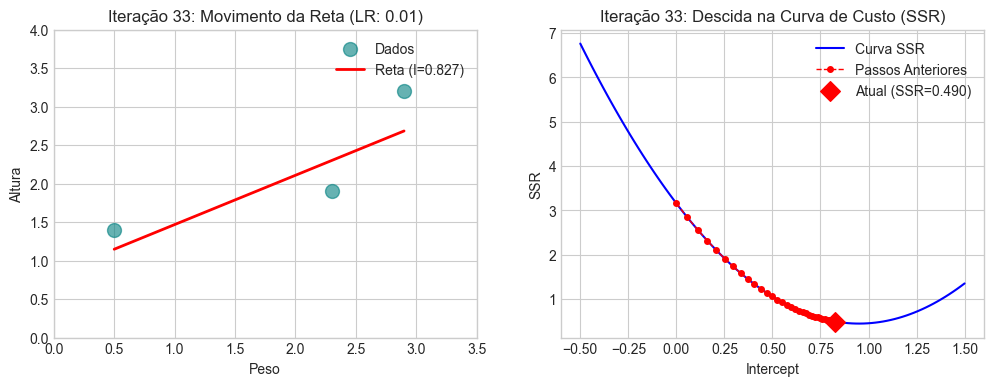

Iter 34: Old I=0.827, Step Size=-0.007, New I=0.835, Grad=-0.740


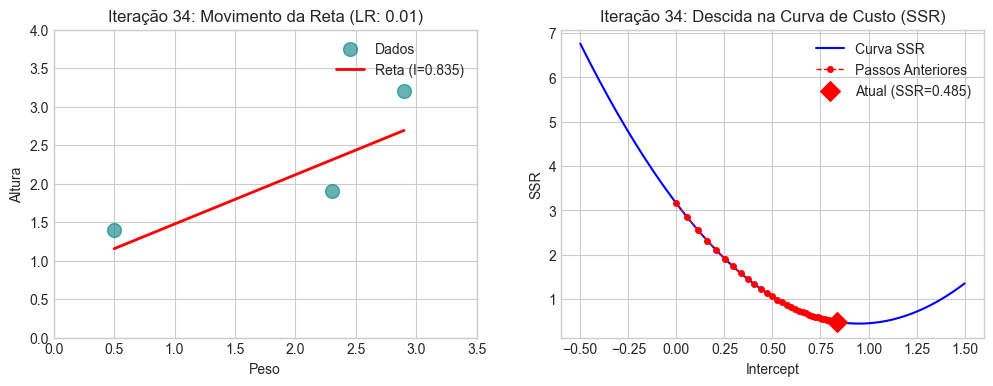

Iter 35: Old I=0.835, Step Size=-0.007, New I=0.842, Grad=-0.696


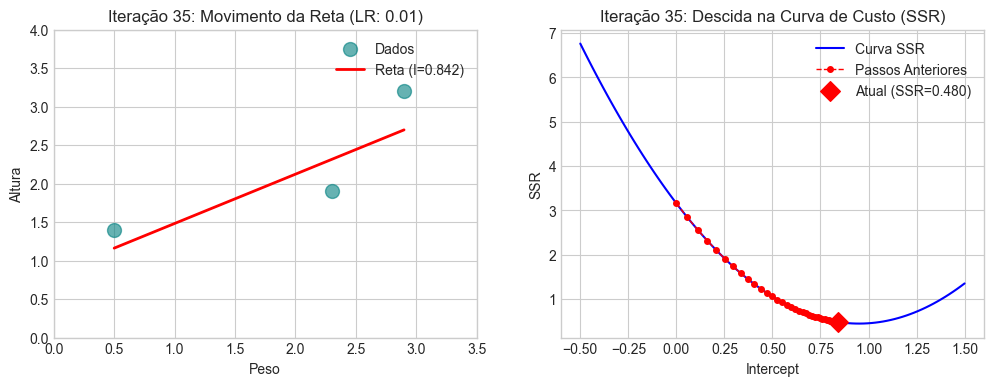

Iter 36: Old I=0.842, Step Size=-0.007, New I=0.848, Grad=-0.654


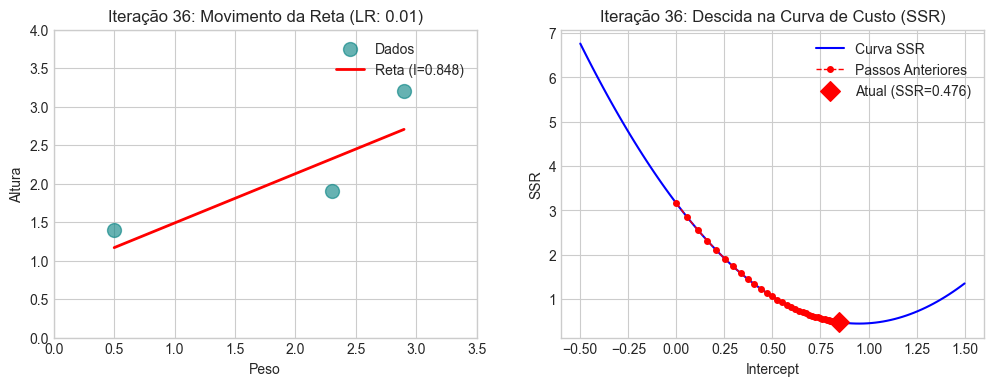

Iter 37: Old I=0.848, Step Size=-0.006, New I=0.854, Grad=-0.615


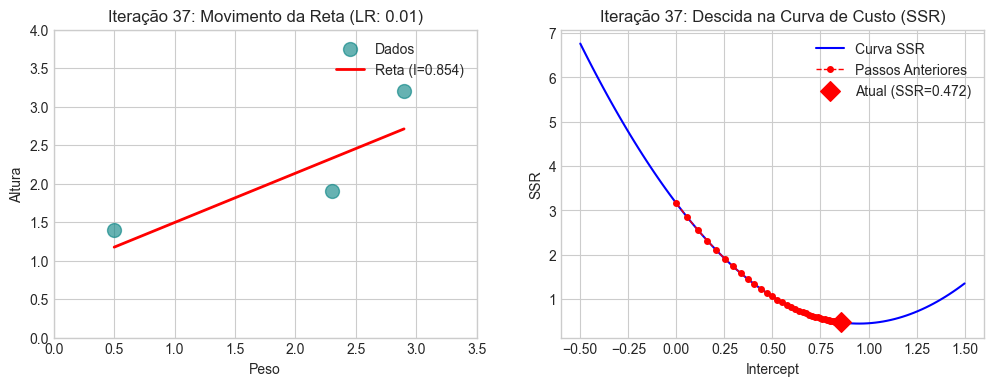

Iter 38: Old I=0.854, Step Size=-0.006, New I=0.860, Grad=-0.578


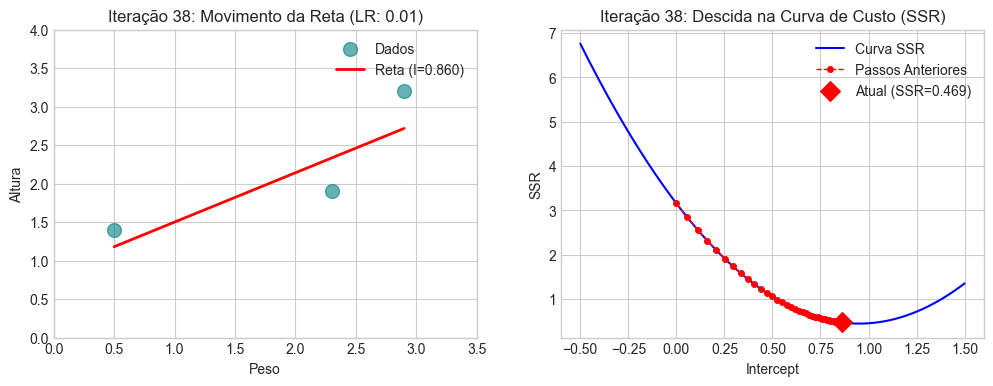

Iter 39: Old I=0.860, Step Size=-0.005, New I=0.866, Grad=-0.543


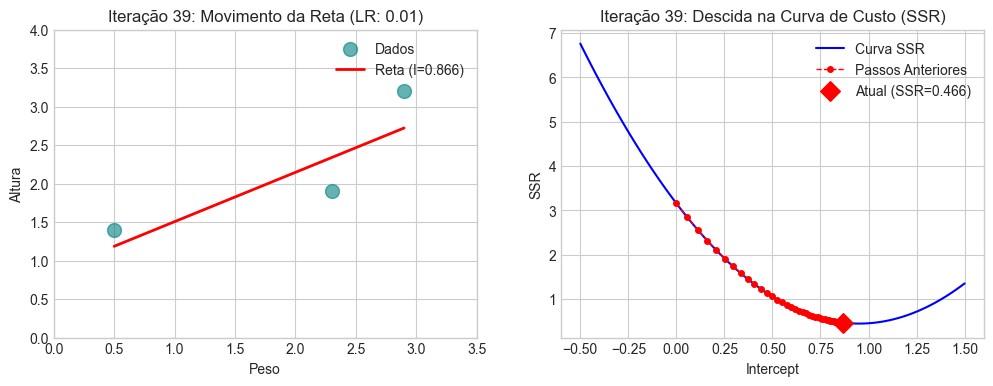

Iter 40: Old I=0.866, Step Size=-0.005, New I=0.871, Grad=-0.511


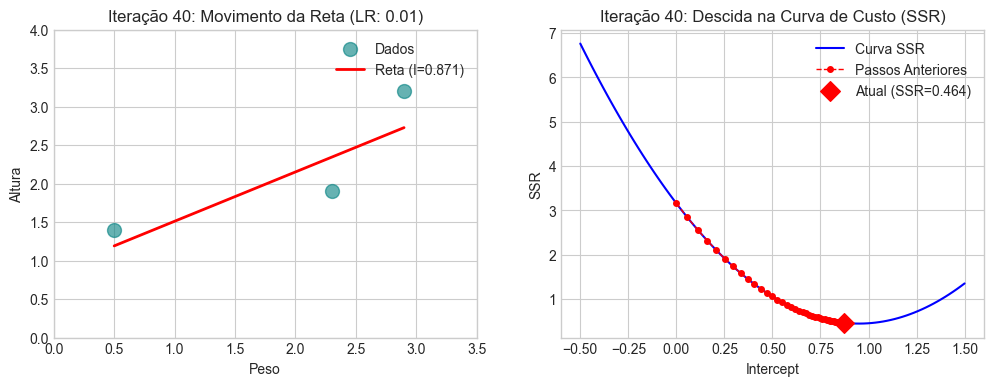

Iter 41: Old I=0.871, Step Size=-0.005, New I=0.875, Grad=-0.480


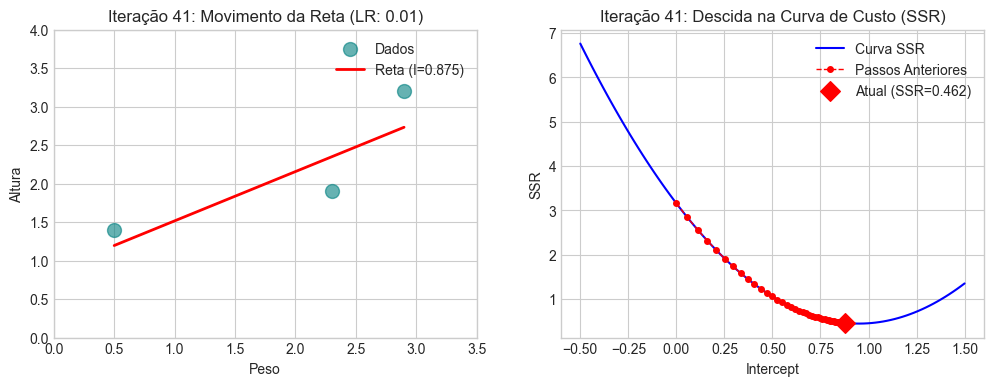

Iter 42: Old I=0.875, Step Size=-0.005, New I=0.880, Grad=-0.451


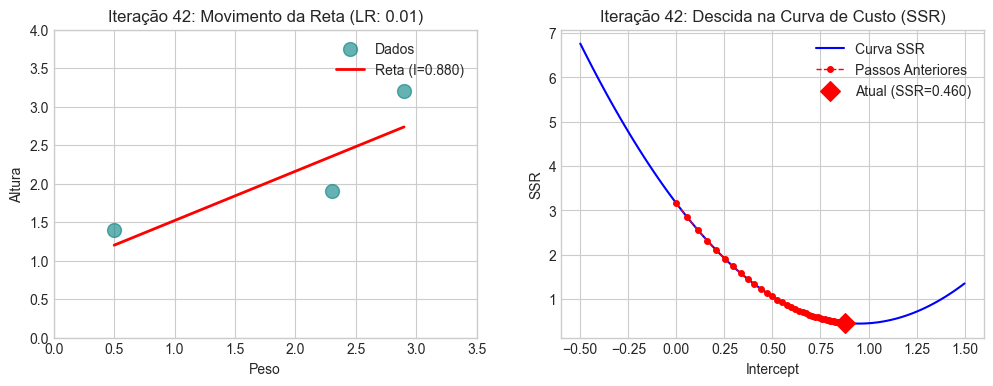

Iter 43: Old I=0.880, Step Size=-0.004, New I=0.884, Grad=-0.424


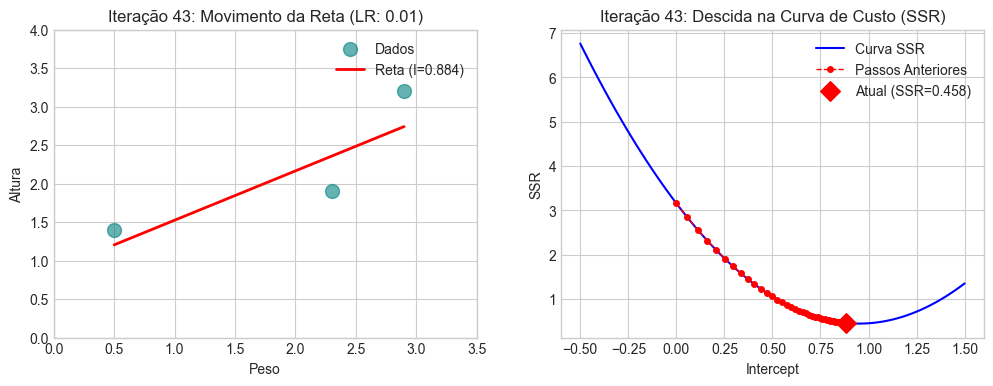

Iter 44: Old I=0.884, Step Size=-0.004, New I=0.888, Grad=-0.399


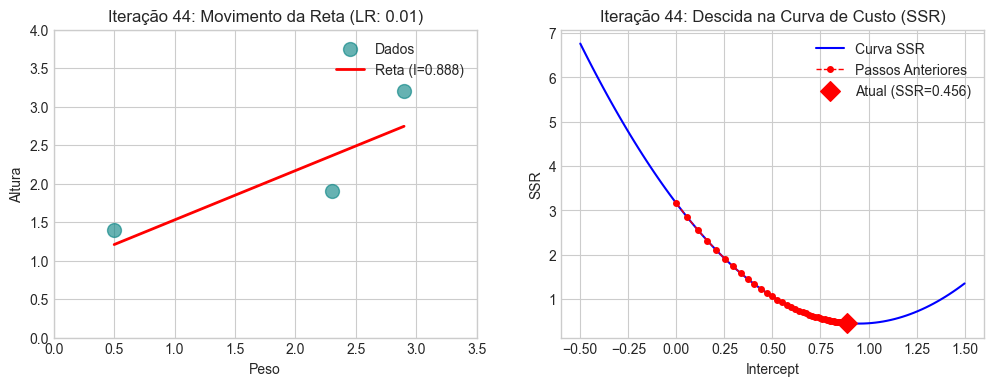

Iter 45: Old I=0.888, Step Size=-0.004, New I=0.892, Grad=-0.375


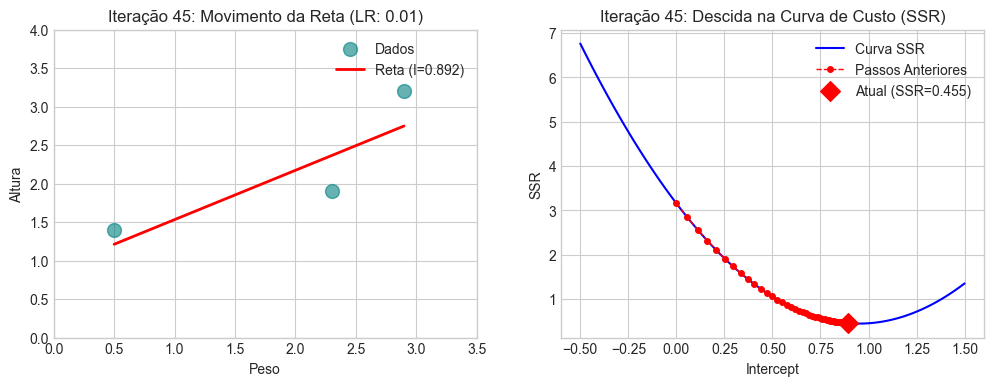

Iter 46: Old I=0.892, Step Size=-0.004, New I=0.895, Grad=-0.352


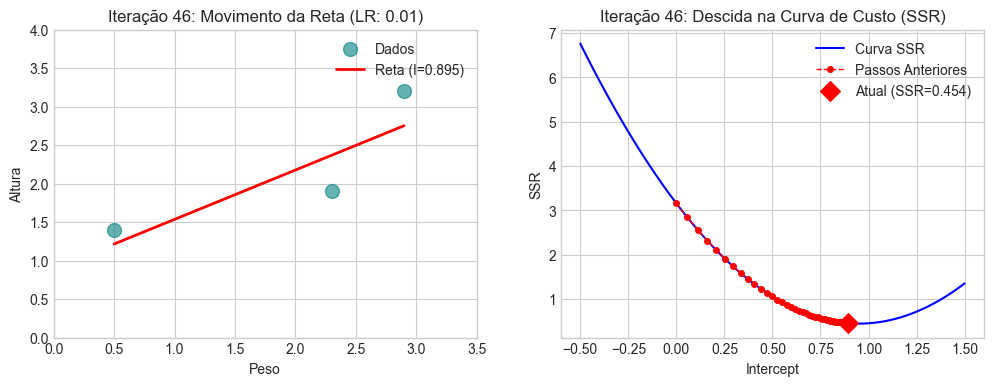

Iter 47: Old I=0.895, Step Size=-0.003, New I=0.899, Grad=-0.331


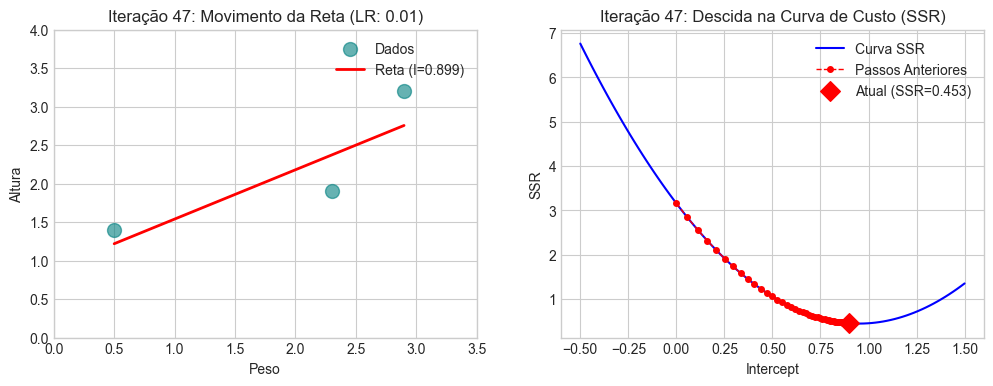

Iter 48: Old I=0.899, Step Size=-0.003, New I=0.902, Grad=-0.311


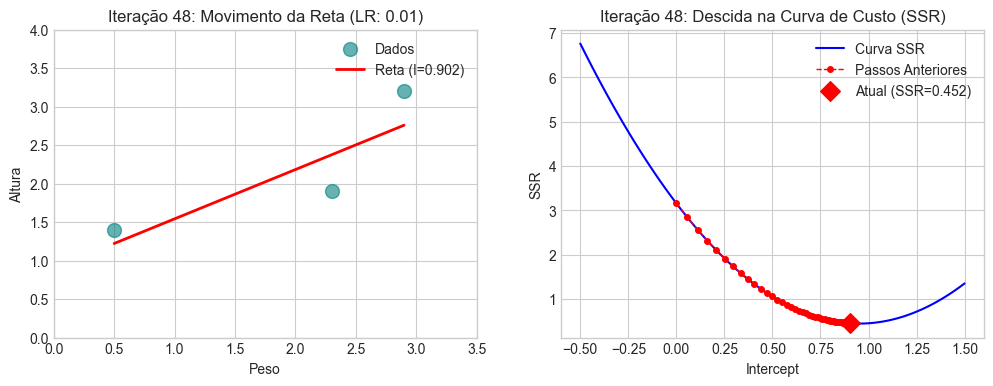

Iter 49: Old I=0.902, Step Size=-0.003, New I=0.905, Grad=-0.293


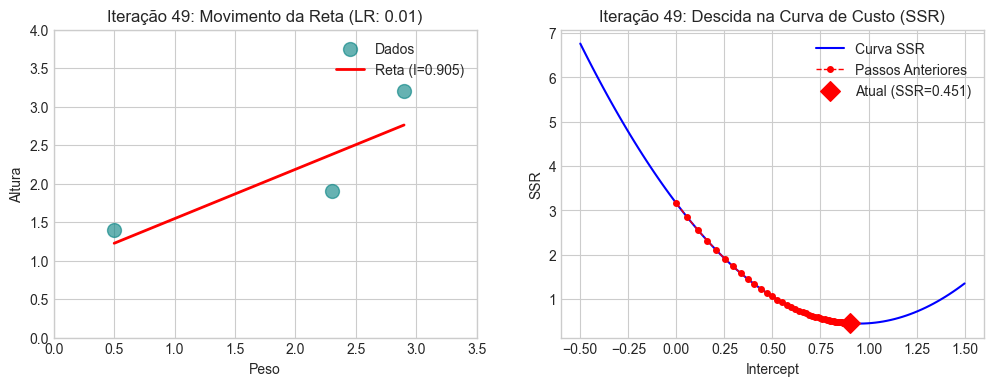

Iter 50: Old I=0.905, Step Size=-0.003, New I=0.908, Grad=-0.275


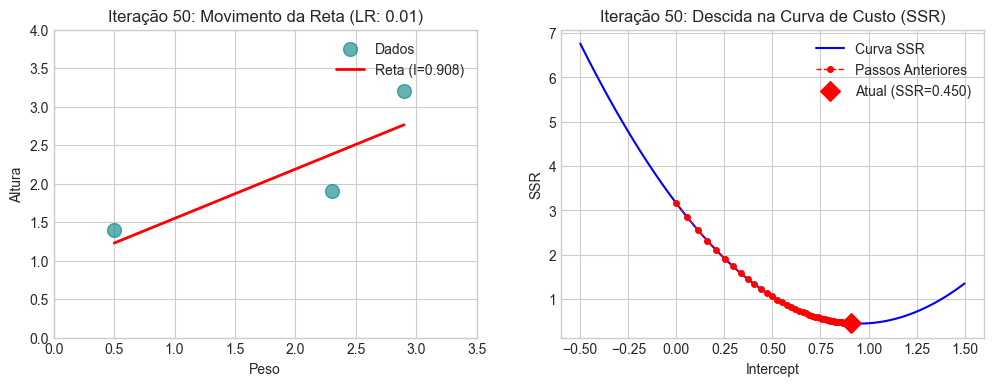

-> Condição de parada: Número máximo de iterações atingido (50).
Resultado Final para LR 0.01: Intercept = 0.9076


In [3]:
# --- Execução da Questão A ---
learning_rates = [0.1, 0.01]
all_intercept_history = {}
all_ssr_history = {}

for lr in learning_rates:
    intercepts, ssrs = run_gradient_descent_and_plot(weights, heights, slope_fixed, initial_intercept, lr, max_iters, tolerance, lr)
    all_intercept_history[lr] = intercepts
    all_ssr_history[lr] = ssrs

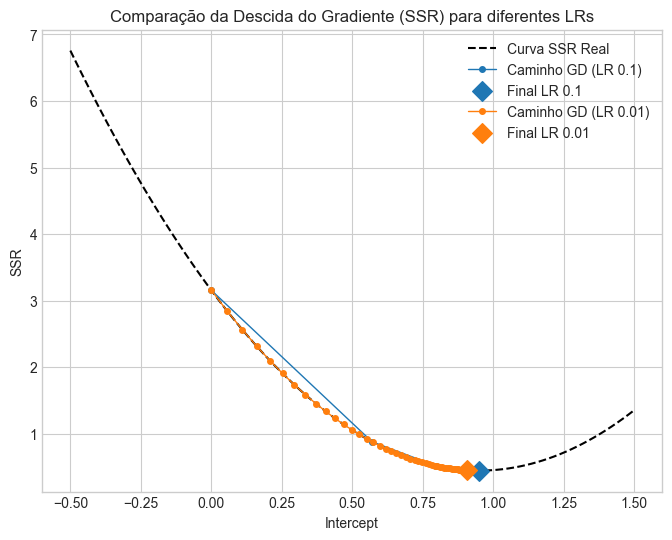

In [4]:
# Comparação final das curvas SSR para a Questão A

plt.figure(figsize=(8, 6))
intercept_vals = np.linspace(-0.5, 1.5, 100)
ssr_vals = [calculate_ssr(i, slope_fixed, weights, heights) for i in intercept_vals]
plt.plot(intercept_vals, ssr_vals, label='Curva SSR Real', color='black', linestyle='--')

# Plotagem dos caminhos para cada LR
for lr, ssr_history in all_ssr_history.items():
    # Caminho completo
    plt.plot(all_intercept_history[lr], ssr_history, marker='o', markersize=4, linestyle='-', linewidth=1, label=f'Caminho GD (LR {lr})')
    # Ponto final
    plt.scatter(all_intercept_history[lr][-1], ssr_history[-1], marker='D', s=100, zorder=5, label=f'Final LR {lr}')

plt.title("Comparação da Descida do Gradiente (SSR) para diferentes LRs")
plt.xlabel("Intercept")
plt.ylabel("SSR")
plt.legend()
plt.show()

## Questão B - Parte 1: Gradiente Descendente (Regressão Linear - Intercepto e Slope)

**Objetivo:** Implementar o GD para otimizar o **Intercept** e o **Slope** (declive) simultaneamente (slides 302-335).
* **Modelo:** $Altura = Intercept + Slope \times Peso$.
* **Início:** Intercepto inicial em **0.0**, Slope inicial em **0.0**.
* **Condições de parada:** Máximo de iterações: $\mathbf{50}$ OU $\lvert Step Size \rvert < \mathbf{0.001}$ (para ambos os parâmetros).
* **LR a testar:** 0.01.
* **Visualização:** Mostrar o movimento da reta a **cada iteração**.


--- Iniciando Gradiente Descendente 2 Parâmetros (LR: 0.01, Max Iters: 50) ---
Iter 1: I Old=0.000, Step I=-0.130, New I=0.130 | S Old=0.000, Step S=-0.287, New S=0.287


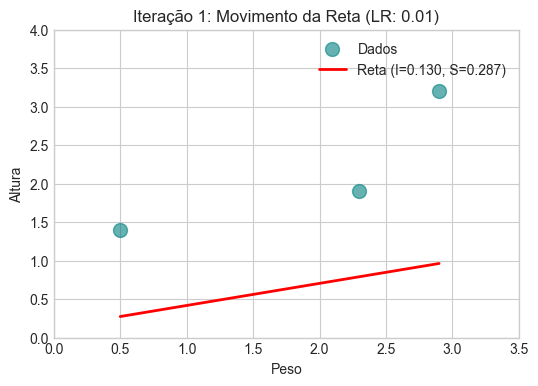

Iter 2: I Old=0.130, Step I=-0.089, New I=0.219 | S Old=0.287, Step S=-0.192, New S=0.479


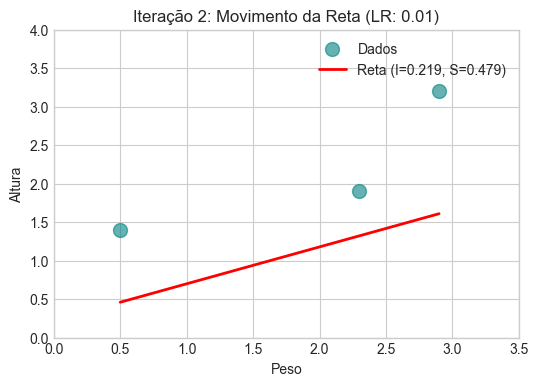

Iter 3: I Old=0.219, Step I=-0.062, New I=0.282 | S Old=0.479, Step S=-0.128, New S=0.607


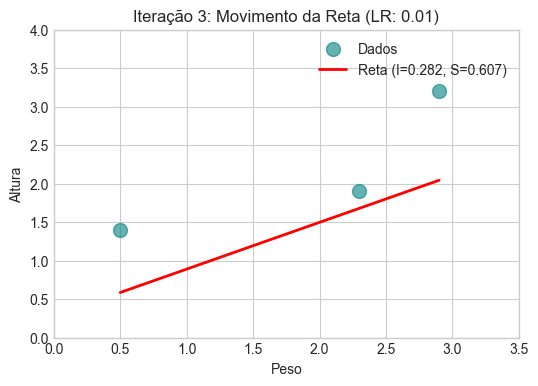

Iter 4: I Old=0.282, Step I=-0.044, New I=0.326 | S Old=0.607, Step S=-0.085, New S=0.693


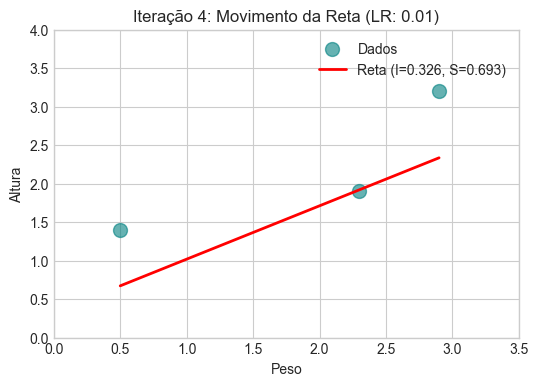

Iter 5: I Old=0.326, Step I=-0.031, New I=0.357 | S Old=0.693, Step S=-0.057, New S=0.749


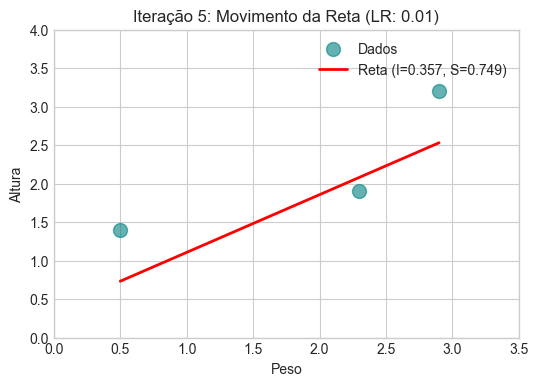

Iter 6: I Old=0.357, Step I=-0.023, New I=0.380 | S Old=0.749, Step S=-0.037, New S=0.787


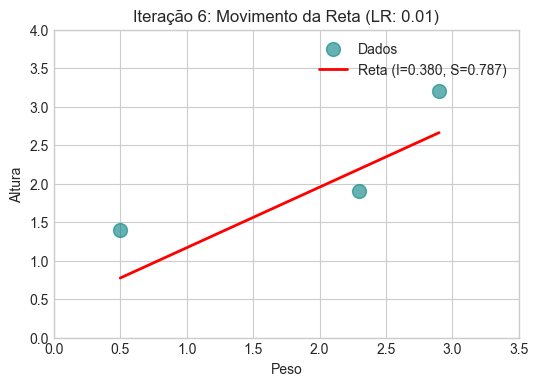

Iter 7: I Old=0.380, Step I=-0.018, New I=0.398 | S Old=0.787, Step S=-0.024, New S=0.811


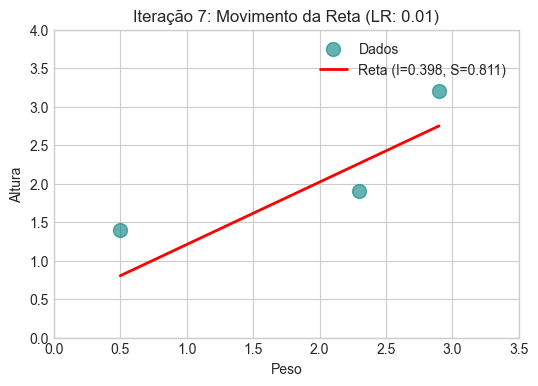

Iter 8: I Old=0.398, Step I=-0.014, New I=0.411 | S Old=0.811, Step S=-0.015, New S=0.826


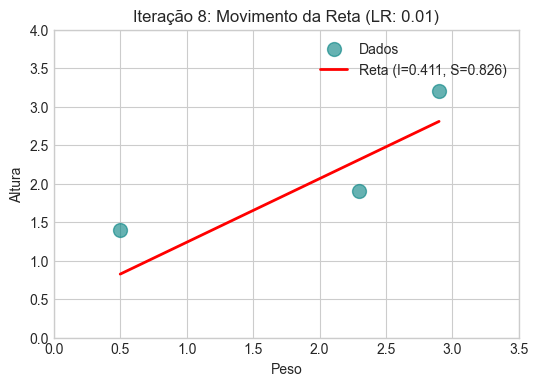

Iter 9: I Old=0.411, Step I=-0.011, New I=0.423 | S Old=0.826, Step S=-0.010, New S=0.836


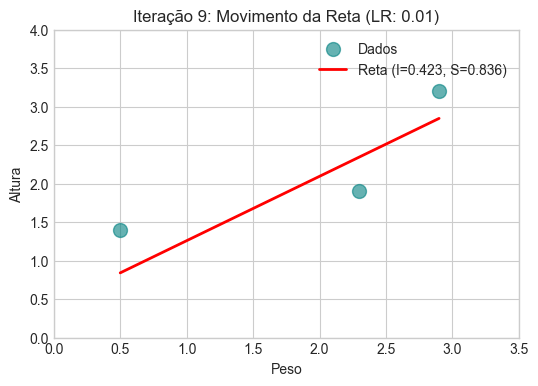

Iter 10: I Old=0.423, Step I=-0.009, New I=0.432 | S Old=0.836, Step S=-0.006, New S=0.841


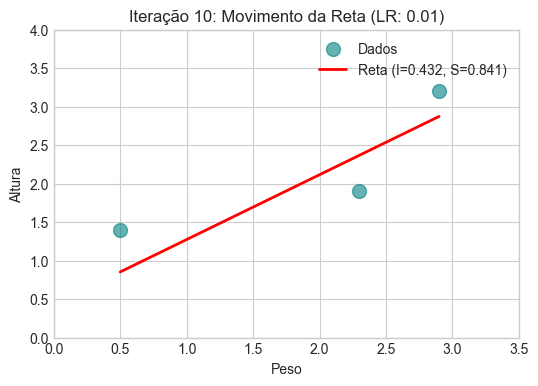

Iter 11: I Old=0.432, Step I=-0.008, New I=0.440 | S Old=0.841, Step S=-0.003, New S=0.844


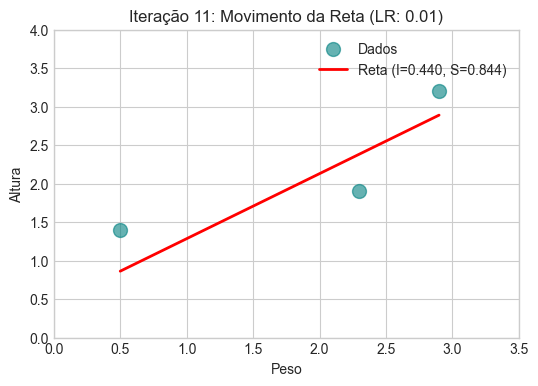

Iter 12: I Old=0.440, Step I=-0.007, New I=0.447 | S Old=0.844, Step S=-0.001, New S=0.846


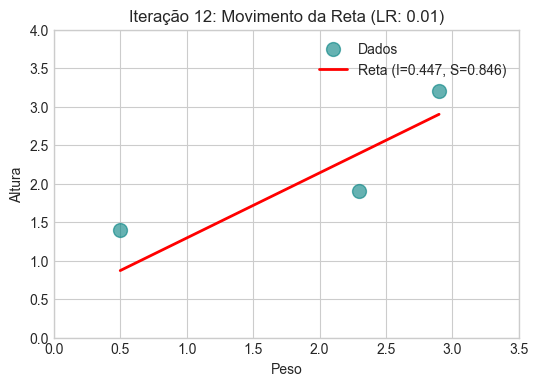

Iter 13: I Old=0.447, Step I=-0.007, New I=0.454 | S Old=0.846, Step S=-0.000, New S=0.846


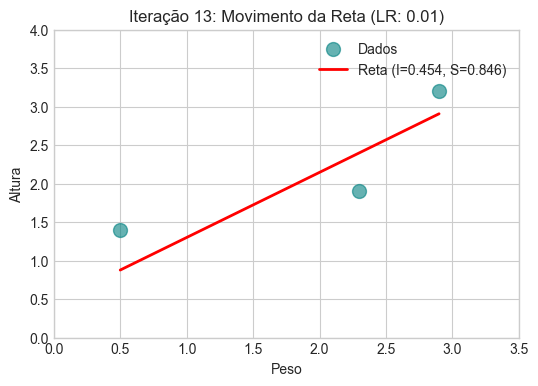

Iter 14: I Old=0.454, Step I=-0.006, New I=0.460 | S Old=0.846, Step S=0.001, New S=0.845


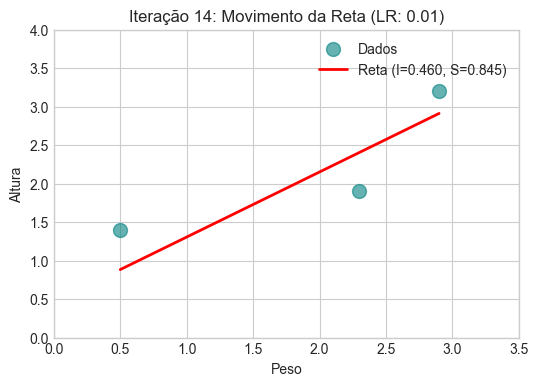

Iter 15: I Old=0.460, Step I=-0.006, New I=0.466 | S Old=0.845, Step S=0.001, New S=0.844


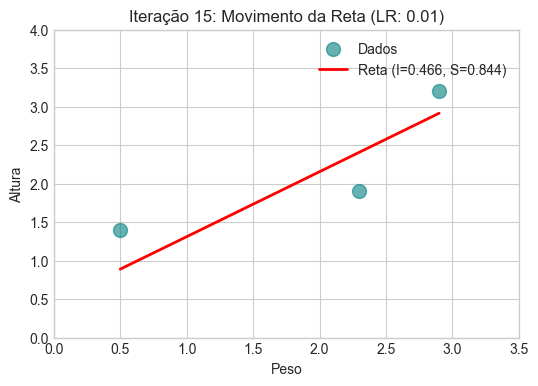

Iter 16: I Old=0.466, Step I=-0.006, New I=0.472 | S Old=0.844, Step S=0.002, New S=0.842


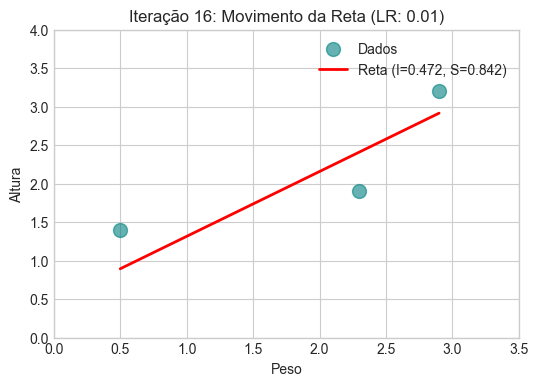

Iter 17: I Old=0.472, Step I=-0.006, New I=0.478 | S Old=0.842, Step S=0.002, New S=0.840


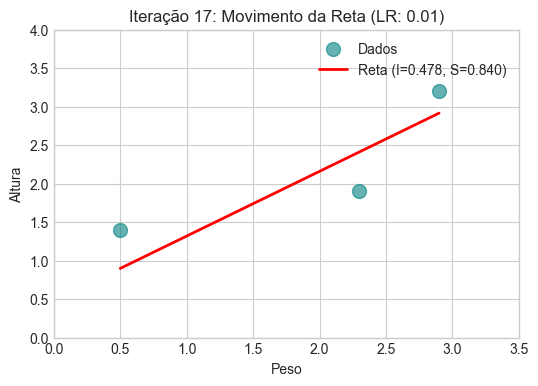

Iter 18: I Old=0.478, Step I=-0.006, New I=0.483 | S Old=0.840, Step S=0.002, New S=0.838


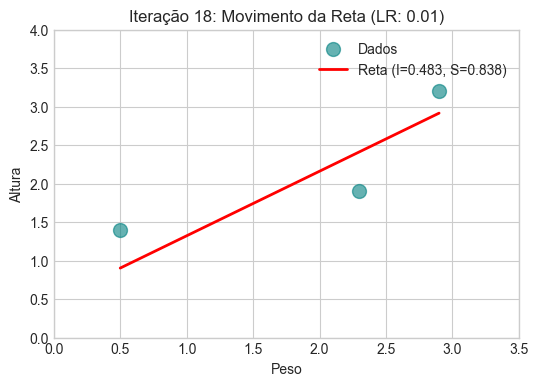

Iter 19: I Old=0.483, Step I=-0.005, New I=0.489 | S Old=0.838, Step S=0.002, New S=0.836


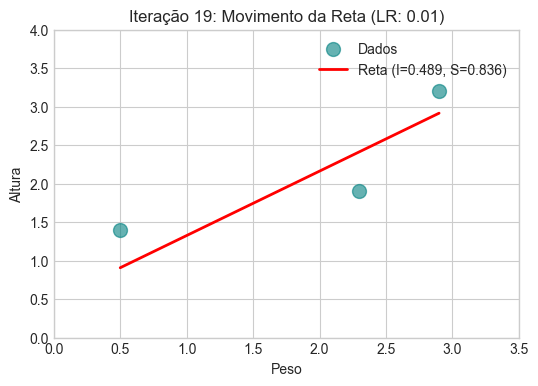

Iter 20: I Old=0.489, Step I=-0.005, New I=0.494 | S Old=0.836, Step S=0.002, New S=0.834


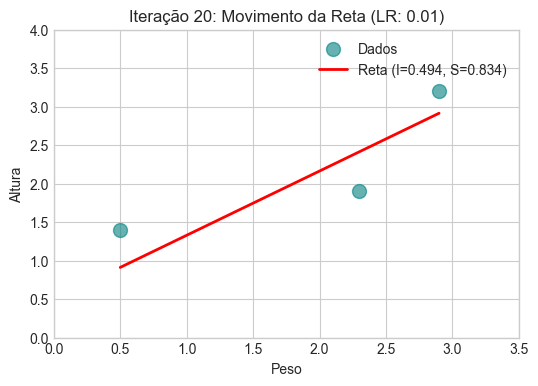

Iter 21: I Old=0.494, Step I=-0.005, New I=0.499 | S Old=0.834, Step S=0.002, New S=0.832


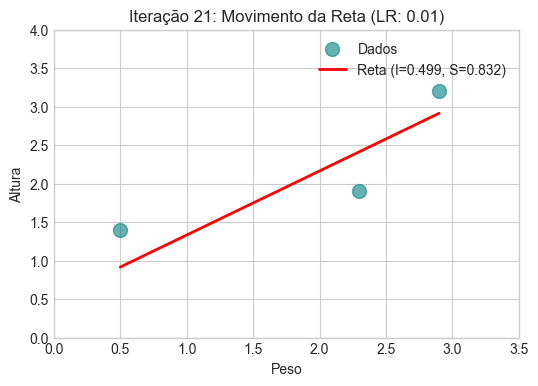

Iter 22: I Old=0.499, Step I=-0.005, New I=0.505 | S Old=0.832, Step S=0.002, New S=0.830


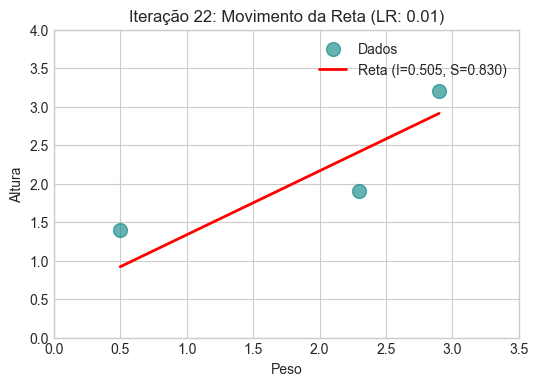

Iter 23: I Old=0.505, Step I=-0.005, New I=0.510 | S Old=0.830, Step S=0.002, New S=0.828


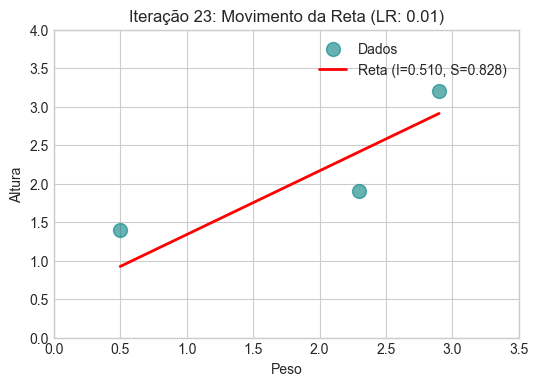

Iter 24: I Old=0.510, Step I=-0.005, New I=0.515 | S Old=0.828, Step S=0.002, New S=0.826


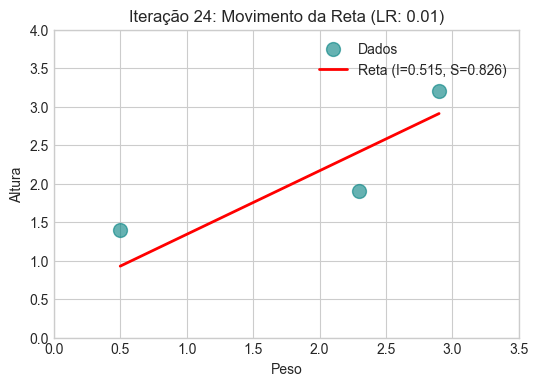

Iter 25: I Old=0.515, Step I=-0.005, New I=0.520 | S Old=0.826, Step S=0.002, New S=0.824


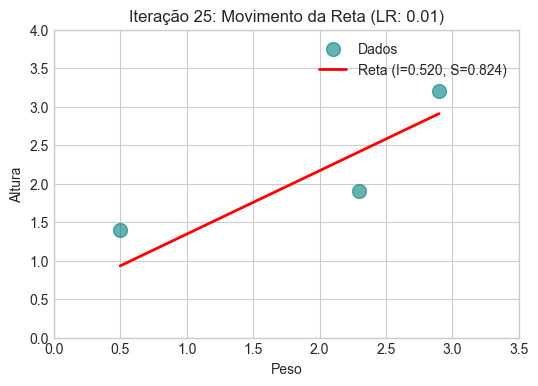

Iter 26: I Old=0.520, Step I=-0.005, New I=0.525 | S Old=0.824, Step S=0.002, New S=0.822


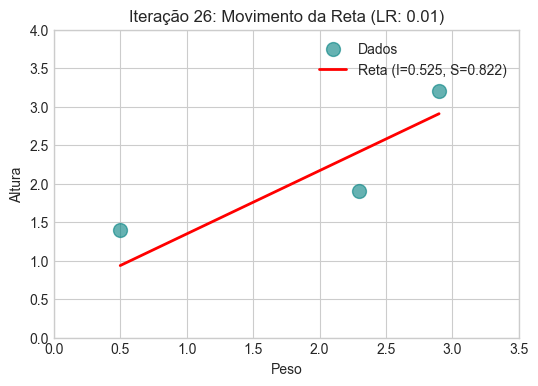

Iter 27: I Old=0.525, Step I=-0.005, New I=0.529 | S Old=0.822, Step S=0.002, New S=0.820


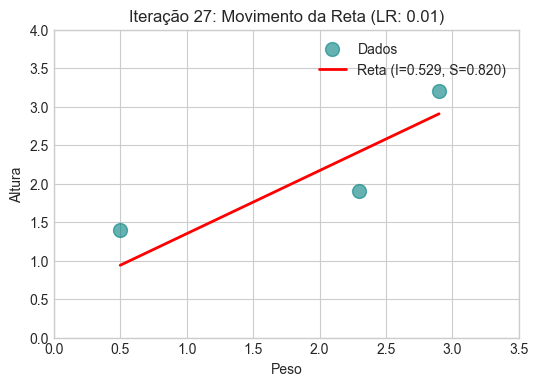

Iter 28: I Old=0.529, Step I=-0.005, New I=0.534 | S Old=0.820, Step S=0.002, New S=0.818


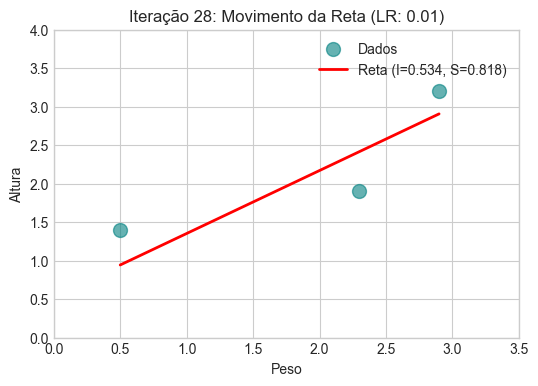

Iter 29: I Old=0.534, Step I=-0.005, New I=0.539 | S Old=0.818, Step S=0.002, New S=0.816


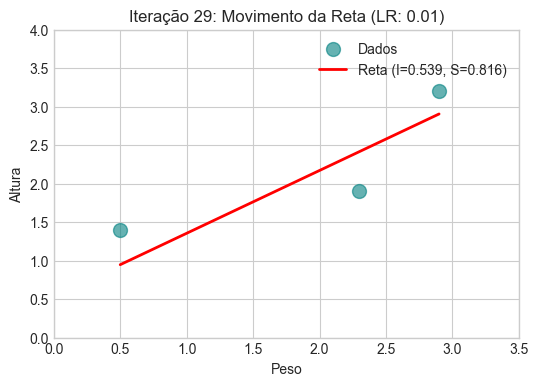

Iter 30: I Old=0.539, Step I=-0.005, New I=0.544 | S Old=0.816, Step S=0.002, New S=0.814


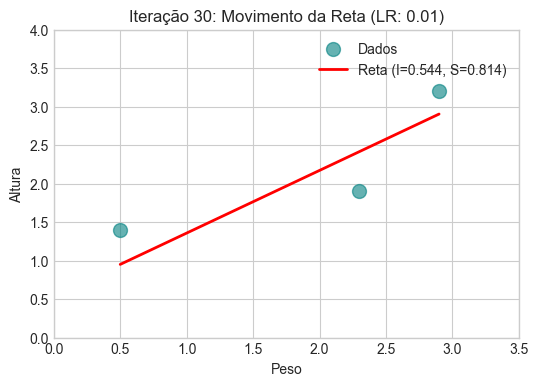

Iter 31: I Old=0.544, Step I=-0.005, New I=0.548 | S Old=0.814, Step S=0.002, New S=0.812


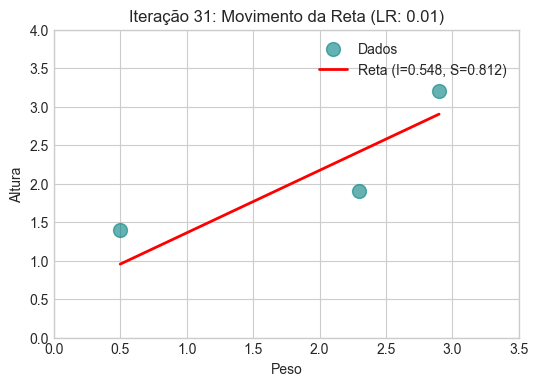

Iter 32: I Old=0.548, Step I=-0.005, New I=0.553 | S Old=0.812, Step S=0.002, New S=0.810


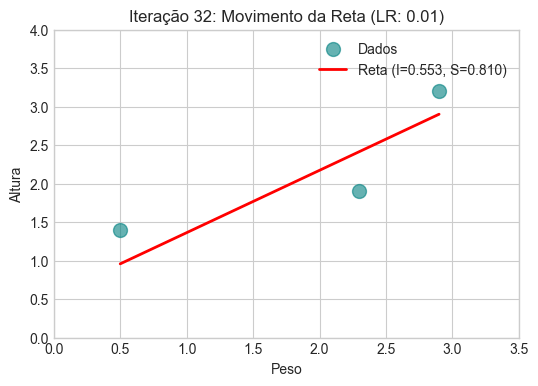

Iter 33: I Old=0.553, Step I=-0.005, New I=0.557 | S Old=0.810, Step S=0.002, New S=0.808


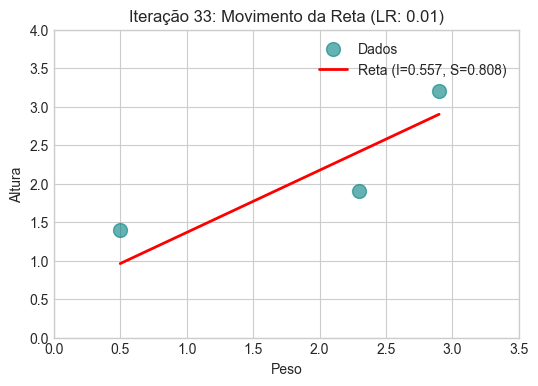

Iter 34: I Old=0.557, Step I=-0.004, New I=0.562 | S Old=0.808, Step S=0.002, New S=0.806


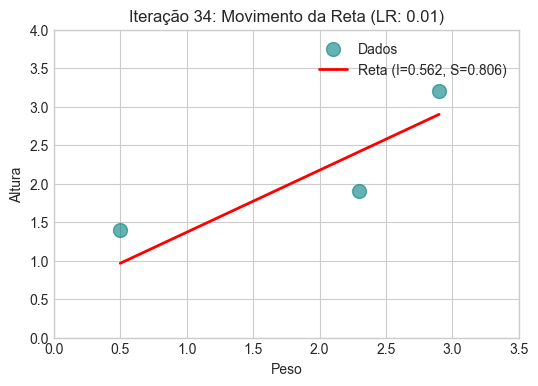

Iter 35: I Old=0.562, Step I=-0.004, New I=0.566 | S Old=0.806, Step S=0.002, New S=0.804


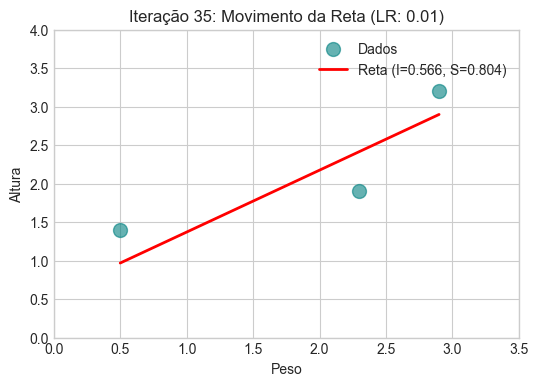

Iter 36: I Old=0.566, Step I=-0.004, New I=0.571 | S Old=0.804, Step S=0.002, New S=0.802


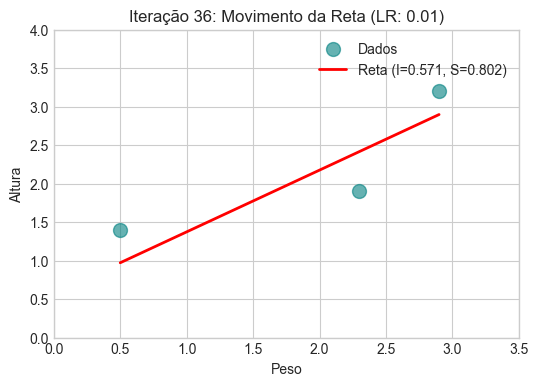

Iter 37: I Old=0.571, Step I=-0.004, New I=0.575 | S Old=0.802, Step S=0.002, New S=0.800


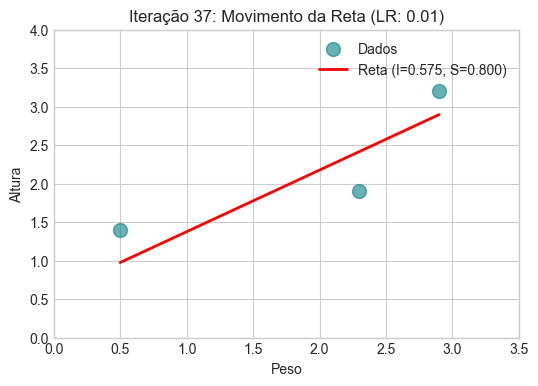

Iter 38: I Old=0.575, Step I=-0.004, New I=0.579 | S Old=0.800, Step S=0.002, New S=0.798


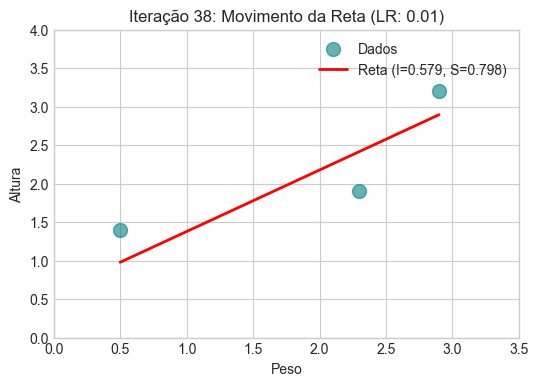

Iter 39: I Old=0.579, Step I=-0.004, New I=0.584 | S Old=0.798, Step S=0.002, New S=0.797


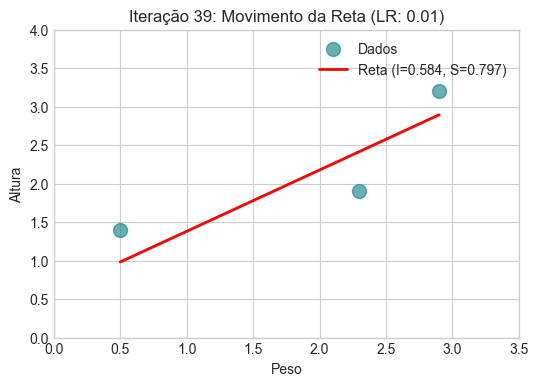

Iter 40: I Old=0.584, Step I=-0.004, New I=0.588 | S Old=0.797, Step S=0.002, New S=0.795


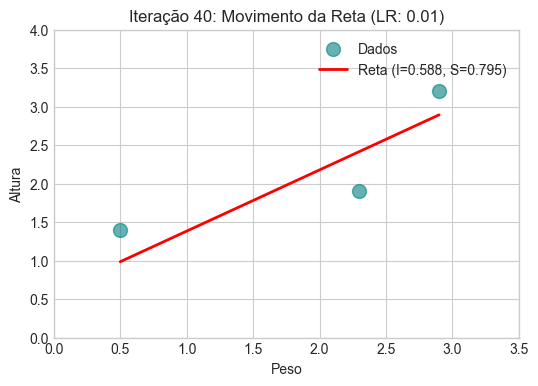

Iter 41: I Old=0.588, Step I=-0.004, New I=0.592 | S Old=0.795, Step S=0.002, New S=0.793


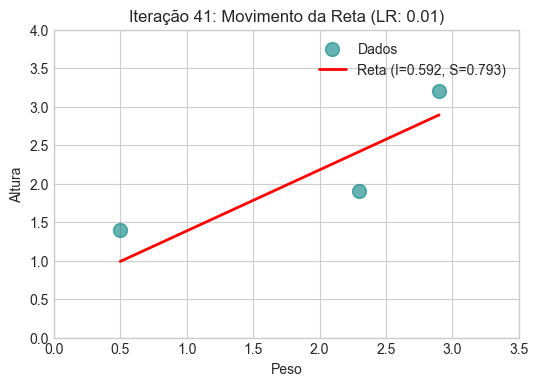

Iter 42: I Old=0.592, Step I=-0.004, New I=0.596 | S Old=0.793, Step S=0.002, New S=0.791


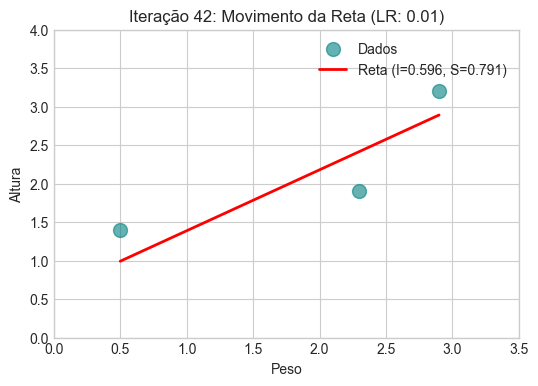

Iter 43: I Old=0.596, Step I=-0.004, New I=0.600 | S Old=0.791, Step S=0.002, New S=0.790


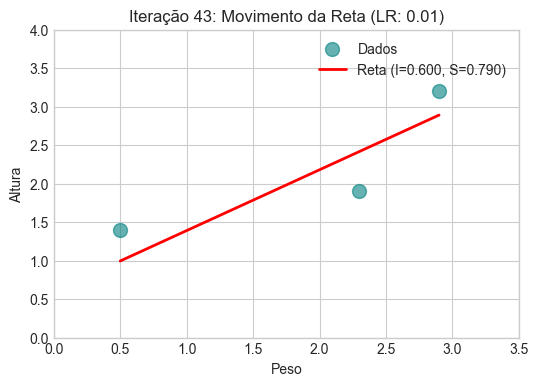

Iter 44: I Old=0.600, Step I=-0.004, New I=0.604 | S Old=0.790, Step S=0.002, New S=0.788


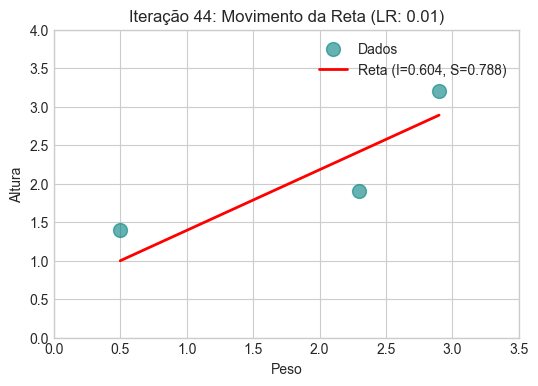

Iter 45: I Old=0.604, Step I=-0.004, New I=0.608 | S Old=0.788, Step S=0.002, New S=0.786


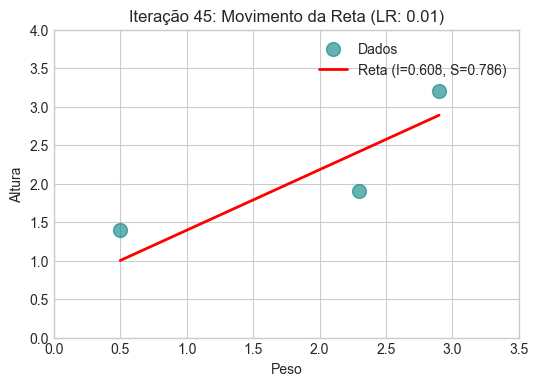

Iter 46: I Old=0.608, Step I=-0.004, New I=0.612 | S Old=0.786, Step S=0.002, New S=0.785


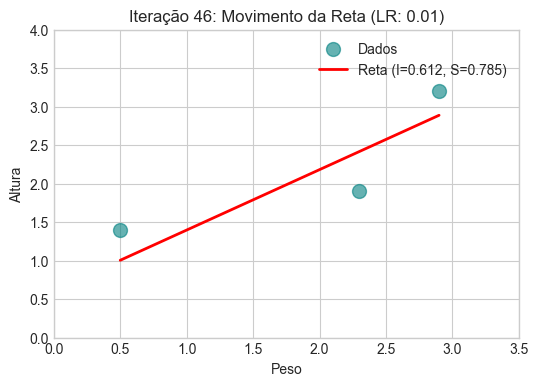

Iter 47: I Old=0.612, Step I=-0.004, New I=0.616 | S Old=0.785, Step S=0.002, New S=0.783


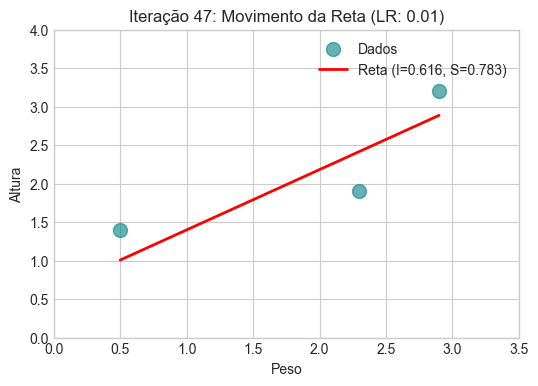

Iter 48: I Old=0.616, Step I=-0.004, New I=0.619 | S Old=0.783, Step S=0.002, New S=0.781


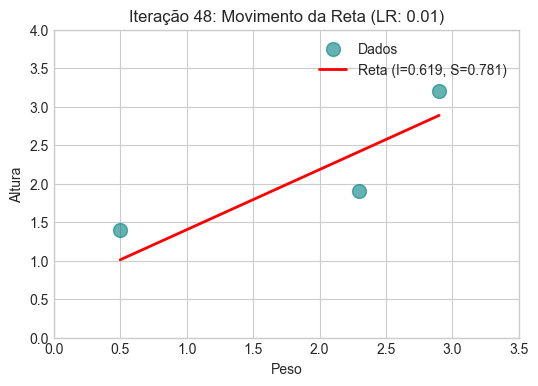

Iter 49: I Old=0.619, Step I=-0.004, New I=0.623 | S Old=0.781, Step S=0.002, New S=0.780


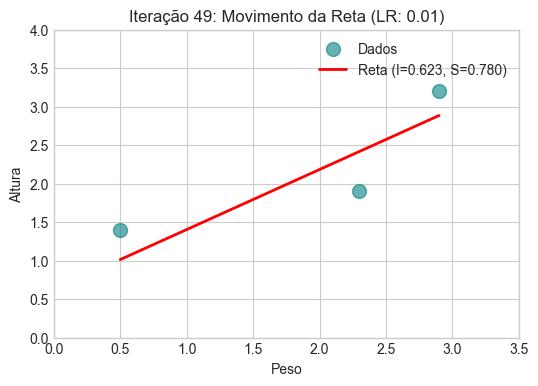

Iter 50: I Old=0.623, Step I=-0.004, New I=0.627 | S Old=0.780, Step S=0.002, New S=0.778


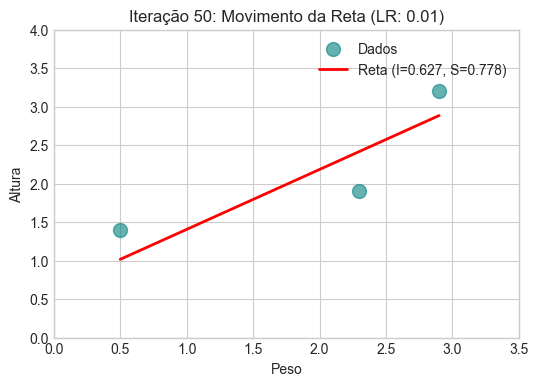

-> Condição de parada: Número máximo de iterações atingido (50).
Resultado Final para LR 0.01: Intercept = 0.6269, Slope = 0.7781


In [5]:
# --- Dados da Questão B ---
weights_B = np.array([0.5, 2.3, 2.9])
heights_B = np.array([1.4, 1.9, 3.2])
learning_rate_B = 0.01
max_iters = 50
tolerance = 0.001
initial_intercept_B = 0.0
initial_slope_B = 0.0

# --- Funções para Gradiente Descendente (2 Parâmetros) ---

def calculate_gradients_two_params(intercept, slope, weights, heights):
    predicted = intercept + slope * weights
    residuals = heights - predicted
    
    # d(SSR)/d(Intercept)
    grad_intercept = np.sum(-2 * residuals)
    
    # d(SSR)/d(Slope)
    grad_slope = np.sum(-2 * residuals * weights)
    
    return grad_intercept, grad_slope

def run_gd_two_params(weights, heights, initial_intercept, initial_slope, lr, max_iters, tolerance):
    
    print(f"\n--- Iniciando Gradiente Descendente 2 Parâmetros (LR: {lr}, Max Iters: {max_iters}) ---")

    intercept = initial_intercept
    slope = initial_slope
    
    for i in range(max_iters):
        # 1. Calcular os Gradientes
        grad_intercept, grad_slope = calculate_gradients_two_params(intercept, slope, weights, heights)
        
        # 2. Calcular os Step Sizes
        step_intercept = grad_intercept * lr
        step_slope = grad_slope * lr
        
        # 4. Atualizar os Parâmetros
        old_intercept = intercept
        old_slope = slope
        
        intercept = intercept - step_intercept
        slope = slope - step_slope
        
        # 5. Imprimir informações a cada iteração
        print(f"Iter {i+1}: I Old={old_intercept:.3f}, Step I={step_intercept:.3f}, New I={intercept:.3f} | S Old={old_slope:.3f}, Step S={step_slope:.3f}, New S={slope:.3f}")
        
        # 6. Mostrar o movimento da reta a CADA iteração
        plt.figure(figsize=(6, 4))
        # Gráfico: Movimento da Reta 
        plt.scatter(weights, heights, color='teal', s=100, alpha=0.6, label='Dados')
        predicted_all = intercept + slope * weights
        plt.plot(weights, predicted_all, color='red', linewidth=2, label=f'Reta (I={intercept:.3f}, S={slope:.3f})')
        plt.title(f"Iteração {i+1}: Movimento da Reta (LR: {lr})")
        plt.xlabel("Peso")
        plt.ylabel("Altura")
        plt.legend()
        plt.ylim(0, 4)
        plt.xlim(0, 3.5)
        plt.show()

        # 3. Condição de Parada
        if abs(step_intercept) < tolerance and abs(step_slope) < tolerance:
            print(f"-> Convergência alcançada (Step Sizes pequenos) na iteração {i+1}.")
            break

    if i == max_iters - 1 and (abs(step_intercept) >= tolerance or abs(step_slope) >= tolerance):
        print("-> Condição de parada: Número máximo de iterações atingido (50).")
    
    print(f"Resultado Final para LR {lr}: Intercept = {intercept:.4f}, Slope = {slope:.4f}")

# --- Execução da Questão B - Parte 1 ---
run_gd_two_params(weights_B, heights_B, initial_intercept_B, initial_slope_B, learning_rate_B, max_iters, tolerance)

## Questão B - Parte 2: Gradiente Descendente Estocástico (SGD) e Mini-Batch GD

**Objetivo:** Adaptar a otimização do **Intercepto** (Slope fixo em 0.64) para rodar com **GD Estocástico (SGD)** e **Mini-Batch GD** (tamanho 2).
* **Modelo:** Usar os mesmos dados e modelo da Questão A.
* **LR a testar:** 0.01.
* **Condições de parada:** $\mathbf{50}$ épocas (SGD) / $\mathbf{50}$ iterações de batch (Mini-Batch).

In [6]:
# --- Dados da Questão B - Parte 2 ---
weights_C = np.array([0.5, 2.3, 2.9])
heights_C = np.array([1.4, 1.9, 3.2])
slope_fixed_C = 0.64
learning_rate_C = 0.01
epochs_sgd = 50 
max_iters_mb = 50 
initial_intercept = 0.0

# --- Funções para SGD e Mini-Batch GD (1 Parâmetro) ---

# Função que executa SGD (Batch Size = 1)
def run_sgd(weights, heights, slope_fixed, initial_intercept, lr, epochs):
    print(f"\n--- Iniciando Gradiente Descendente Estocástico (LR: {lr}, Max Epochs: {epochs}) ---")
    
    intercept = initial_intercept
    
    for epoch in range(epochs):
        # Embaralhar os dados a cada época
        indices = np.arange(len(weights))
        np.random.shuffle(indices)
        
        # Itera sobre todas as amostras
        for i in indices:
            w_sample = weights[i]
            h_sample = heights[i]
            
            # 1. Predição e Resíduo (para 1 amostra)
            pred_sample = intercept + slope_fixed * w_sample
            residual = h_sample - pred_sample
            
            # 2. Gradiente (derivada para 1 amostra)
            derivative = -2 * residual
            
            # 3. Step Size
            step_size = derivative * lr
            
            # 4. Atualizar o Intercept
            old_intercept = intercept
            intercept = intercept - step_size
            
        # Imprimir o valor do intercepto no final de cada época
        print(f"Epoch {epoch+1}: Old I={old_intercept:.4f}, Step Size={step_size:.4f}, New I={intercept:.4f}")

    print(f"Resultado Final SGD para LR {lr}: Intercept = {intercept:.4f}")
    return intercept

# Função que executa Mini-Batch GD
def run_minibatch_gd(weights, heights, slope_fixed, initial_intercept, lr, max_iters, batch_size):
    print(f"\n--- Iniciando Mini-Batch GD (Batch Size: {batch_size}, LR: {lr}, Max Steps: {max_iters}) ---")
    
    intercept = initial_intercept
    step_count = 0
    n_samples = len(weights)

    # Loop de iterações (batches)
    for _ in range(max_iters):
        step_count += 1
        
        # Embaralhar os dados e selecionar o primeiro mini-batch
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        batch_indices = indices[0:batch_size]
        
        w_batch = weights[batch_indices]
        h_batch = heights[batch_indices]
        
        # 1. Predição e Resíduos
        pred_batch = intercept + slope_fixed * w_batch
        residuals = h_batch - pred_batch
        
        # 2. Gradiente (médio para o batch)
        derivative = np.sum(-2 * residuals) / len(w_batch)
        
        # 3. Step Size
        step_size = derivative * lr
        
        # 4. Atualizar o Intercept
        old_intercept = intercept
        intercept = intercept - step_size
        
        # Imprimir informações a cada passo
        print(f"Passo {step_count}: Old I={old_intercept:.4f}, Step Size={step_size:.4f}, New I={intercept:.4f}")

    print(f"Resultado Final Mini-Batch GD para LR {lr}: Intercept = {intercept:.4f}")
    return intercept

# --- Execução da Questão B - Parte 2 ---
sgd_intercept = run_sgd(weights_C, heights_C, slope_fixed_C, initial_intercept, learning_rate_C, epochs_sgd)

minibatch_intercept = run_minibatch_gd(weights_C, heights_C, slope_fixed_C, initial_intercept, learning_rate_C, max_iters_mb, 2)


--- Iniciando Gradiente Descendente Estocástico (LR: 0.01, Max Epochs: 50) ---
Epoch 1: Old I=0.0300, Step Size=-0.0263, New I=0.0563
Epoch 2: Old I=0.0840, Step Size=-0.0252, New I=0.1092
Epoch 3: Old I=0.1402, Step Size=-0.0188, New I=0.1590
Epoch 4: Old I=0.2007, Step Size=-0.0045, New I=0.2053
Epoch 5: Old I=0.2451, Step Size=-0.0037, New I=0.2487
Epoch 6: Old I=0.2689, Step Size=-0.0215, New I=0.2904
Epoch 7: Old I=0.3089, Step Size=-0.0207, New I=0.3296
Epoch 8: Old I=0.3518, Step Size=-0.0146, New I=0.3664
Epoch 9: Old I=0.3998, Step Size=-0.0006, New I=0.4004
Epoch 10: Old I=0.4325, Step Size=0.0001, New I=0.4325
Epoch 11: Old I=0.4451, Step Size=-0.0180, New I=0.4630
Epoch 12: Old I=0.4744, Step Size=-0.0174, New I=0.4918
Epoch 13: Old I=0.5023, Step Size=-0.0168, New I=0.5192
Epoch 14: Old I=0.5335, Step Size=-0.0109, New I=0.5444
Epoch 15: Old I=0.5529, Step Size=-0.0158, New I=0.5687
Epoch 16: Old I=0.5942, Step Size=0.0033, New I=0.5909
Epoch 17: Old I=0.6028, Step Size=-

### Questão B - Comparação de Métodos

Comparando a convergência para otimização do **Intercepto** (Slope fixo em 0.64) com LR=0.01:

| Método | Granularidade | Convergência (50 passos/épocas) | Estabilidade |
| :--- | :--- | :--- | :--- |
| **Batch GD** (Parte 1) | Todo o dataset (3 amostras) | Converge rapidamente (em poucas iterações) para o ótimo global ($\approx 0.9500$). | Mais estável, caminho suave. |
| **SGD** (Parte 2) | 1 amostra por passo (3 passos por época) | Se aproxima do ótimo, mas o passo final exato depende da ordem aleatória dos dados. | Mais ruidoso (flutuações nos passos), mas rápido no início. |
| **Mini-Batch GD** (Parte 2) | 2 amostras por passo | Se aproxima do ótimo, com um equilíbrio entre velocidade e estabilidade. | Menos ruidoso que SGD, mas mais que Batch GD. |

O **Batch GD** é o mais eficiente para este pequeno dataset. Em datasets grandes, o **Mini-Batch GD** (e SGD) se torna a escolha preferencial devido à eficiência computacional e capacidade de evitar mínimos locais rasos.

## Questão D: Gradiente Descendente em Redes Neurais (Otimização de $b_3$)

**Objetivo:** Implementar o GD para otimizar apenas o **Bias $b_3$** de uma rede neural (slides 256-305).
* **Arquitetura:** 1 Entrada (Dosage), 2 Neurônios Ocultos (Softplus), 1 Saída (Identidade).
* **Dados:** (Dosage, Output) $\rightarrow$ **(0, 0), (0.5, 1), (1.0, 0)**.
* **LR/Condições:** LR = 0.01, Máx. iterações: $\mathbf{50}$, $\lvert Step Size \rvert < 0.001$.

In [7]:
# --- Funções de Ativação ---
# Softplus: f(x) = log(1 + e^x)
def softplus(x):
    # Para evitar overflow, limitamos o expoente para exp(x)
    return np.log(1 + np.exp(np.clip(x, -50, 50)))

# --- Dados e Parâmetros (D) ---
X_D = np.array([0, 0.5, 1.0])
Y_D = np.array([0, 1, 0])
# Pesos Fixos/Otimizados (Verdes)
w1, b1 = 3.34, -1.43
w2, b2 = -3.53, 0.57
w3_fixed, w4_fixed = -1.22, -2.30

# Parâmetros a Otimizar (Iniciais)
initial_b3 = 0.0 
lr_D = 0.01
max_iters = 50
tolerance = 0.001

def run_nn_gd_b3(X, Y, w1, b1, w2, b2, w3_fixed, w4_fixed, initial_b3, lr, max_iters, tolerance):
    
    print(f"\n--- Iniciando GD em RN (Otimizando b3, LR: {lr}, Max Iters: {max_iters}) ---")

    b3 = initial_b3
    
    # 1. Pré-cálculos (Forward Pass dos pesos fixos)
    Z1 = w1 * X + b1
    A1 = softplus(Z1) 
    Z2 = w2 * X + b2
    A2 = softplus(Z2)
    S = w3_fixed * A1 + w4_fixed * A2 # Valor "base" do squiggle (sem b3)
    
    for i in range(max_iters):
        
        # 1. Forward Pass (Calcula Y_pred)
        Y_pred = S + b3 
        
        # 2. Backpropagation: Derivada do Custo em relação a b3
        # d(SSR)/d(b3) = sum(-2 * (Y - Y_pred) * 1)
        dC_db3 = -2 * (Y - Y_pred)
        grad_b3 = np.sum(dC_db3)
        
        # 3. Step Size
        step_b3 = grad_b3 * lr
        
        # 4. Condição de Parada
        if abs(step_b3) < tolerance:
            print(f"-> Convergência alcançada (Step Size < {tolerance}) na iteração {i+1}.")
            break
            
        # 5. Atualizar b3
        old_b3 = b3
        b3 = b3 - step_b3
        
        # 6. Imprimir informações a cada iteração
        print(f"Iter {i+1}: Old b3={old_b3:.5f}, Step Size={step_b3:.5f}, New b3={b3:.5f}, Grad b3={grad_b3:.5f}")

    if i == max_iters - 1 and abs(step_b3) >= tolerance:
        print("-> Condição de parada: Número máximo de iterações atingido (50).")
    
    print(f"Resultado Final para b3 (LR {lr}): b3 = {b3:.5f}")

# --- Execução da Questão D ---
run_nn_gd_b3(X_D, Y_D, w1, b1, w2, b2, w3_fixed, w4_fixed, initial_b3, lr_D, max_iters, tolerance)


--- Iniciando GD em RN (Otimizando b3, LR: 0.01, Max Iters: 50) ---
Iter 1: Old b3=0.00000, Step Size=-0.15655, New b3=0.15655, Grad b3=-15.65511
Iter 2: Old b3=0.15655, Step Size=-0.14716, New b3=0.30371, Grad b3=-14.71580
Iter 3: Old b3=0.30371, Step Size=-0.13833, New b3=0.44204, Grad b3=-13.83285
Iter 4: Old b3=0.44204, Step Size=-0.13003, New b3=0.57207, Grad b3=-13.00288
Iter 5: Old b3=0.57207, Step Size=-0.12223, New b3=0.69429, Grad b3=-12.22271
Iter 6: Old b3=0.69429, Step Size=-0.11489, New b3=0.80919, Grad b3=-11.48935
Iter 7: Old b3=0.80919, Step Size=-0.10800, New b3=0.91719, Grad b3=-10.79999
Iter 8: Old b3=0.91719, Step Size=-0.10152, New b3=1.01871, Grad b3=-10.15199
Iter 9: Old b3=1.01871, Step Size=-0.09543, New b3=1.11414, Grad b3=-9.54287
Iter 10: Old b3=1.11414, Step Size=-0.08970, New b3=1.20384, Grad b3=-8.97030
Iter 11: Old b3=1.20384, Step Size=-0.08432, New b3=1.28816, Grad b3=-8.43208
Iter 12: Old b3=1.28816, Step Size=-0.07926, New b3=1.36742, Grad b3=-7.92

## Questão E: Gradiente Descendente em Redes Neurais (Otimização de 3 Parâmetros)

**Objetivo:** Implementar o GD para otimizar **$w_3, w_4$ e $b_3$** simultaneamente (slides 231-279).
* **Parâmetros Fixos (Otimizados):** $w_1=3.34, b_1=-1.43, w_2=-3.53, b_2=0.57$.
* **Parâmetros a Otimizar (Iniciais):** $w_3=0.36, w_4=0.63, b_3=0.00$.
* **LR/Condições:** LR = 0.01, Máx. iterações: $\mathbf{50}$, $\lvert Step Size \rvert < 0.001$ para **todos** os parâmetros.

In [8]:
# --- Dados e Parâmetros (E) ---
X_E = np.array([0, 0.5, 1.0])
Y_E = np.array([0, 1, 0])
# Pesos Fixos/Otimizados (Verdes)
w1, b1 = 3.34, -1.43
w2, b2 = -3.53, 0.57

# Parâmetros a Otimizar (Iniciais - Vermelhos)
w3 = 0.36
w4 = 0.63
b3 = 0.0

lr_E = 0.01
max_iters = 50
tolerance = 0.001

def run_nn_gd_three_params(X, Y, w1, b1, w2, b2, initial_w3, initial_w4, initial_b3, lr, max_iters, tolerance):
    
    print(f"\n--- Iniciando GD em RN (Otimizando w3, w4, b3, LR: {lr}, Max Iters: {max_iters}) ---")

    w3 = initial_w3
    w4 = initial_w4
    b3 = initial_b3
    
    # 1. Pré-cálculos (Forward Pass dos pesos fixos)
    Z1 = w1 * X + b1
    A1 = softplus(Z1) 
    Z2 = w2 * X + b2
    A2 = softplus(Z2)
    
    for i in range(max_iters):
        
        # 1. Forward Pass (Calcula Y_pred)
        S = w3 * A1 + w4 * A2
        Y_pred = S + b3 
        
        # 2. Backpropagation: Derivadas do Custo (SSR)
        dC_dY_pred = -2 * (Y - Y_pred)
        
        # Gradientes finais (soma sobre todas as amostras)
        grad_b3 = np.sum(dC_dY_pred * 1)
        grad_w3 = np.sum(dC_dY_pred * A1) # Multiplica pela ativação do nó de entrada
        grad_w4 = np.sum(dC_dY_pred * A2) # Multiplica pela ativação do nó de entrada
        
        # 3. Step Sizes
        step_w3 = grad_w3 * lr
        step_w4 = grad_w4 * lr
        step_b3 = grad_b3 * lr
        
        # 4. Condição de Parada
        if abs(step_w3) < tolerance and abs(step_w4) < tolerance and abs(step_b3) < tolerance:
            print(f"-> Convergência alcançada na iteração {i+1}.")
            break

        # 5. Atualizar Parâmetros
        old_w3, old_w4, old_b3 = w3, w4, b3
        
        w3 = w3 - step_w3
        w4 = w4 - step_w4
        b3 = b3 - step_b3
        
        # 6. Imprimir informações a cada iteração
        print(f"Iter {i+1}:")
        print(f"   w3: Old={old_w3:.5f}, Step={step_w3:.5f}, New={w3:.5f}, Grad={grad_w3:.5f}")
        print(f"   w4: Old={old_w4:.5f}, Step={step_w4:.5f}, New={w4:.5f}, Grad={grad_w4:.5f}")
        print(f"   b3: Old={old_b3:.5f}, Step={step_b3:.5f}, New={b3:.5f}, Grad={grad_b3:.5f}")

    if i == max_iters - 1 and not (abs(step_w3) < tolerance and abs(step_w4) < tolerance and abs(step_b3) < tolerance):
        print("-> Condição de parada: Número máximo de iterações atingido (50).")
    
    print(f"\nResultado Final (LR {lr}): w3 = {w3:.5f}, w4 = {w4:.5f}, b3 = {b3:.5f}")

# --- Execução da Questão E ---
run_nn_gd_three_params(X_E, Y_E, w1, b1, w2, b2, w3, w4, b3, lr_E, max_iters, tolerance)


--- Iniciando GD em RN (Otimizando w3, w4, b3, LR: 0.01, Max Iters: 50) ---
Iter 1:
   w3: Old=0.36000, Step=0.02576, New=0.33424, Grad=2.57614
   w4: Old=0.63000, Step=0.01257, New=0.61743, Grad=1.25676
   b3: Old=0.00000, Step=0.01900, New=-0.01900, Grad=1.89955
Iter 2:
   w3: Old=0.33424, Step=0.02192, New=0.31232, Grad=2.19230
   w4: Old=0.61743, Step=0.01150, New=0.60593, Grad=1.15047
   b3: Old=-0.01900, Step=0.01593, New=-0.03493, Grad=1.59323
Iter 3:
   w3: Old=0.31232, Step=0.01866, New=0.29365, Grad=1.86622
   w4: Old=0.60593, Step=0.01059, New=0.59534, Grad=1.05884
   b3: Old=-0.03493, Step=0.01332, New=-0.04825, Grad=1.33178
Iter 4:
   w3: Old=0.29365, Step=0.01589, New=0.27776, Grad=1.58930
   w4: Old=0.59534, Step=0.00980, New=0.58554, Grad=0.97972
   b3: Old=-0.04825, Step=0.01109, New=-0.05933, Grad=1.10857
Iter 5:
   w3: Old=0.27776, Step=0.01354, New=0.26422, Grad=1.35420
   w4: Old=0.58554, Step=0.00911, New=0.57643, Grad=0.91130
   b3: Old=-0.05933, Step=0.00918, N